In [1]:
import pandas as pd
import pickle
import torch
from torch.utils.data import DataLoader, Subset
import os
import numpy as np
import sys
# Aggiunge la cartella src al path
sys.path.append(os.path.abspath('../src'))
# Ora puoi importare normalmente
from data_class import Nuc_Dataset
from utils import training_validation_and_test_loop_classification
from model import CadmusDNA,TransformerNuc_Cadmus
from collections import Counter

from sklearn.model_selection import StratifiedKFold, train_test_split
import math
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from Bio.Seq import Seq
import random

In [2]:
#CARICAMENTO DATI

In [3]:
###
RC_augmentation = True

#Train dataset

with open('../data/data_pkl/Lymphoblastoid_99_8_percentile.pkl', 'rb') as f:   
    dataset_sapiens_lymphoblastoid = pickle.load(f)

if RC_augmentation:
    for d1, d2 in zip(dataset_sapiens_lymphoblastoid, dataset_sapiens_lymphoblastoid):
        d1['sequence_rev'] = str(Seq(d1['sequence']).reverse_complement())

#test dataset act

with open('../data/data_pkl/CD4T_h19_Act_tot_99_8_percentile.pkl', 'rb') as f:   
    dataset_sapiens_cd4t_act = pickle.load(f)
if RC_augmentation:
    for d1, d2 in zip(dataset_sapiens_cd4t_act, dataset_sapiens_cd4t_act):
        d1['sequence_rev'] = str(Seq(d1['sequence']).reverse_complement())


with open('../data/data_pkl/CD4T_h19_Rest_tot_99_8_percentile.pkl', 'rb') as f:   
    dataset_sapiens_cd4t_rest = pickle.load(f)
if RC_augmentation:
    for d1, d2 in zip(dataset_sapiens_cd4t_rest, dataset_sapiens_cd4t_rest):
        d1['sequence_rev'] = str(Seq(d1['sequence']).reverse_complement())



len(dataset_sapiens_lymphoblastoid)

194716

In [4]:
def set_seed(seed=42):
    random.seed(seed)                          # Seed Python (modulo random)
    np.random.seed(seed)                       # Seed NumPy
    torch.manual_seed(seed)                    # Seed PyTorch CPU
    torch.cuda.manual_seed(seed)               # Seed PyTorch CUDA (una GPU)
    torch.cuda.manual_seed_all(seed)           # Seed PyTorch CUDA (tutte le GPU)

    torch.backends.cudnn.deterministic = True  # Usa algoritmi deterministici
    torch.backends.cudnn.benchmark = False     # Disabilita ottimizzazioni non deterministiche

    print(f"Seeds fixed with seed = {seed}")
set_seed()

Seeds fixed with seed = 42


In [5]:
# best_hyperparameters = {'dropout_rate': 0.3143462158665756,
#  'num_heads': 8,
#  'batch_size': 32,
#  'lr': 1.4271180164633878e-06,
#  'weight_decay': 1.2306663346888495e-06,
#  'patience': 12}

best_hyperparameters = {'dropout_rate': 0.3832290311184182, 'num_heads': 5,
                       'batch_size': 32, 'lr': 2.3270677083837795e-06,
                       'weight_decay': 8.179499475211672e-08, 'patience': 10}


# #CV WITH EARLY STOPPING

from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef, roc_auc_score
import numpy as np

def classification_metrics(y_true, probs_pred, threshold=0.5):
    """
    Calcola Sensitivity, Specificity, Accuracy, MCC e AUC
    a partire da y_true (etichette vere) e probs_pred (probabilità predette).
    
    Parametri:
        y_true: array-like di etichette vere (0 o 1)
        probs_pred: array-like di probabilità predette (float tra 0 e 1)
        threshold: soglia di classificazione (default 0.5)
    
    Ritorna:
        dizionario con le metriche richieste
    """
    # Conversione in predizioni binarie
    y_pred = (np.array(probs_pred) >= threshold).astype(int)
    y_true = np.array(y_true)
    
    # Matrice di confusione
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Metriche
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    auc = roc_auc_score(y_true, probs_pred)
    
    return {
        "Sensitivity_val": sensitivity,
        "Specificity_val": specificity,
        "Accuracy_val": accuracy,
        "MCC_val": mcc,
        "AUC_val": auc
    }

    

g = torch.Generator()
g.manual_seed(0) # Usa lo stesso seed

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dim_embedding = 2560#1280#2560
# data = [x for x in data if x['embedding'].shape[0] == 37]#[:3000] 

# dataset_train = Nuc_Dataset(dataset_sapiens_lymphoblastoid, dim_embedding, drop_last=False)
# dataset_test_act = Nuc_Dataset(dataset_sapiens_cd4t_act, dim_embedding, drop_last=False)
# dataset_test_rest = Nuc_Dataset(dataset_sapiens_cd4t_rest, dim_embedding, drop_last=False)

# dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, worker_init_fn=seed_worker, generator=g, drop_last=False )
# dataloader_test_act = DataLoader(dataset_test_act, batch_size=32, shuffle=False, worker_init_fn=seed_worker, generator=g, drop_last=False )
# dataloader_test_rest = DataLoader(dataset_test_rest, batch_size=32, shuffle=False, worker_init_fn=seed_worker, generator=g, drop_last=False )

dataset_train = Nuc_Dataset(dataset_sapiens_lymphoblastoid,max_length=37, rc_augmentation=True)# dim_embedding, drop_last=False)
dataset_test_act = Nuc_Dataset(dataset_sapiens_cd4t_act,max_length=37, rc_augmentation=True)# dim_embedding, drop_last=False)
dataset_test_rest = Nuc_Dataset(dataset_sapiens_cd4t_rest,max_length=37, rc_augmentation=True)# dim_embedding, drop_last=False)

dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, worker_init_fn=seed_worker, generator=g, drop_last=False )
dataloader_test_act = DataLoader(dataset_test_act, batch_size=32, shuffle=False, worker_init_fn=seed_worker, generator=g, drop_last=False )
dataloader_test_rest = DataLoader(dataset_test_rest, batch_size=32, shuffle=False, worker_init_fn=seed_worker, generator=g, drop_last=False )



transf_parameters_att = {'input_dim': dim_embedding, 
                         'dropout_rate': best_hyperparameters['dropout_rate'], 
                         'num_heads': best_hyperparameters['num_heads']}   



In [6]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader

# ==========================================
# 1. SELEZIONE DATASET (Selezionane SOLO UNO)
# ==========================================
LYMPHO_DATA = False   # <--- Metti True qui
ACT_DATA = True    # <--- False
REST_DATA = False    # <--- False

assert LYMPHO_DATA + ACT_DATA + REST_DATA == 1, "Seleziona esattamente un dataset!"

if LYMPHO_DATA:
    dataset_to_study = dataset_sapiens_lymphoblastoid
    DATA_TYPE = 'lymphoblastoid'
elif ACT_DATA:
    dataset_to_study = dataset_sapiens_cd4t_act
    DATA_TYPE = 'act'
elif REST_DATA:
    dataset_to_study = dataset_sapiens_cd4t_rest
    DATA_TYPE = 'rest'

# Nota: 'test' loader non sembra essere usato nel loop di caricamento file, 
# ma lo lascio se ti serve dopo.
test = DataLoader(dataset_to_study, batch_size=64, shuffle=False)

# ==========================================
# 2. CARICAMENTO MATRICI (ENSEMBLE)
# ==========================================
total_matrices_dir = None
total_matrices_rc = None
n_folds = 5

for fold in range(n_folds):
    print(f"Caricando fold {fold}...")
    # Assicurati che i file esistano
    data = torch.load(f"../results/matrices_results_fold{fold}_{DATA_TYPE}.pt")
    
    # torch.stack serve solo se data['...'] è una lista di tensori.
    # Se è già un tensore grande [N, 28, 28], stack non serve (o darà errore).
    # Assumiamo sia una lista come da script precedenti:
    current_dir = torch.stack(data['matrices_dir']) 
    current_rc = torch.stack(data['matrices_rc'])
    
    if fold == 0:
        total_matrices_dir = current_dir
        total_matrices_rc = current_rc
    else:
        total_matrices_dir += current_dir
        total_matrices_rc += current_rc

# Media sui fold
avg_matrices_dir = total_matrices_dir / n_folds
avg_matrices_rc = total_matrices_rc / n_folds

print("Ensemble completato. Shape totale:", avg_matrices_dir.shape)

# ==========================================
# 3. PREPARAZIONE LABELS E PREDIZIONI
# ==========================================
val_labels = [sample['label'] for sample in dataset_to_study]

# Carica predizioni (Assicurati che l'ordine corrisponda!)
# Se preds è una Series pandas, convertiamo in numpy/list per sicurezza
preds_raw = pd.read_pickle(f'preds_{DATA_TYPE}_model_sum_folds_16_02_26.pkl')#(f"preds_{DATA_TYPE}_model_sum_folds.pkl") !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
preds_int = (preds_raw > 0.5).astype(int) # Converte boolean in 0/1

# Controllo sicurezza
assert len(val_labels) == len(preds_int), "Errore: Lunghezza dataset e predizioni non coincidono!"
assert len(val_labels) == avg_matrices_dir.shape[0], "Errore: Lunghezza dataset e matrici non coincidono!"

# ==========================================
# 4. FILTRAGGIO (Selezionane SOLO UNO)
# ==========================================
ALL_PREDS = False
ONLY_POS_PREDS = False  # <--- Esempio: voglio solo i True Positives (Nucleosomi corretti)
ONLY_NEG_PREDS = True

assert ALL_PREDS + ONLY_POS_PREDS + ONLY_NEG_PREDS == 1, "Seleziona un solo tipo di filtro!"

# Creiamo una MASCHERA (lista di booleani) per filtrare sia i dati che le matrici
mask = []

if ALL_PREDS:
    mask = [True] * len(val_labels)
    print("Selezionati: TUTTI i campioni")

elif ONLY_POS_PREDS:
    # True Positive: Predetto 1 (Nucleosoma) E Reale 1
    mask = [(p == 1 and tl == 1) for p, tl in zip(preds_int, val_labels)]
    print("Selezionati: SOLO TRUE POSITIVES (Nucleosomi predetti correttamente)")

elif ONLY_NEG_PREDS:
    # True Negative: Predetto 0 (Linker) E Reale 0
    mask = [(p == 0 and tl == 0) for p, tl in zip(preds_int, val_labels)]
    print("Selezionati: SOLO TRUE NEGATIVES (Linker predetti correttamente)")

# ==========================================
# 5. APPLICAZIONE FILTRO E SALVATAGGIO ALL_PREDS
# ==========================================
from itertools import compress

# 1. SALVATAGGIO DATI COMPLETI (ALL_PREDS)
# Salviamo una copia dei dati originali prima di sovrascriverli col filtro
dataset_all = dataset_to_study
matrices_dir_all = avg_matrices_dir
matrices_rc_all = avg_matrices_rc

# Convertiamo la maschera in tensore per slicing efficiente
mask_tensor = torch.tensor(mask, dtype=torch.bool)

if mask_tensor.sum() == 0:
    print("ATTENZIONE: Nessun campione soddisfa i criteri scelti!")
else:
    # 2. Filtra le matrici (Cruciale!)
    filtered_matrices_dir = avg_matrices_dir[mask_tensor]
    filtered_matrices_rc = avg_matrices_rc[mask_tensor]
    
    # 3. Filtra il dataset (Opzionale, se ti serve recuperare le sequenze)
    data_reduced = list(compress(dataset_to_study, mask))

    print(f"Shape finale filtrata (Current Selection): {filtered_matrices_dir.shape}")
    print(f"Shape originale (ALL_PREDS): {matrices_dir_all.shape}")
    
    # 4. ASSEGNAZIONE VARIABILI PER PLOTTING
    # Assegna alle variabili standard quelle filtrate (così lo script dopo usa queste)
    avg_matrices_dir = filtered_matrices_dir
    avg_matrices_rc = filtered_matrices_rc
    dataset_to_study = data_reduced 

    # NOTA:
    # Ora hai due set di variabili disponibili:
    # 1. FILTRATE (usate dallo script plotting): avg_matrices_dir, dataset_to_study
    # 2. COMPLETE (usate come background): matrices_dir_all, dataset_all

Caricando fold 0...
Caricando fold 1...
Caricando fold 2...
Caricando fold 3...
Caricando fold 4...
Ensemble completato. Shape totale: torch.Size([125822, 37, 37])
Selezionati: SOLO TRUE NEGATIVES (Linker predetti correttamente)
Shape finale filtrata (Current Selection): torch.Size([62591, 37, 37])
Shape originale (ALL_PREDS): torch.Size([125822, 37, 37])


/tmp/ipykernel_610086/105514604.py:112: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  mask_tensor = torch.tensor(mask, dtype=torch.bool)


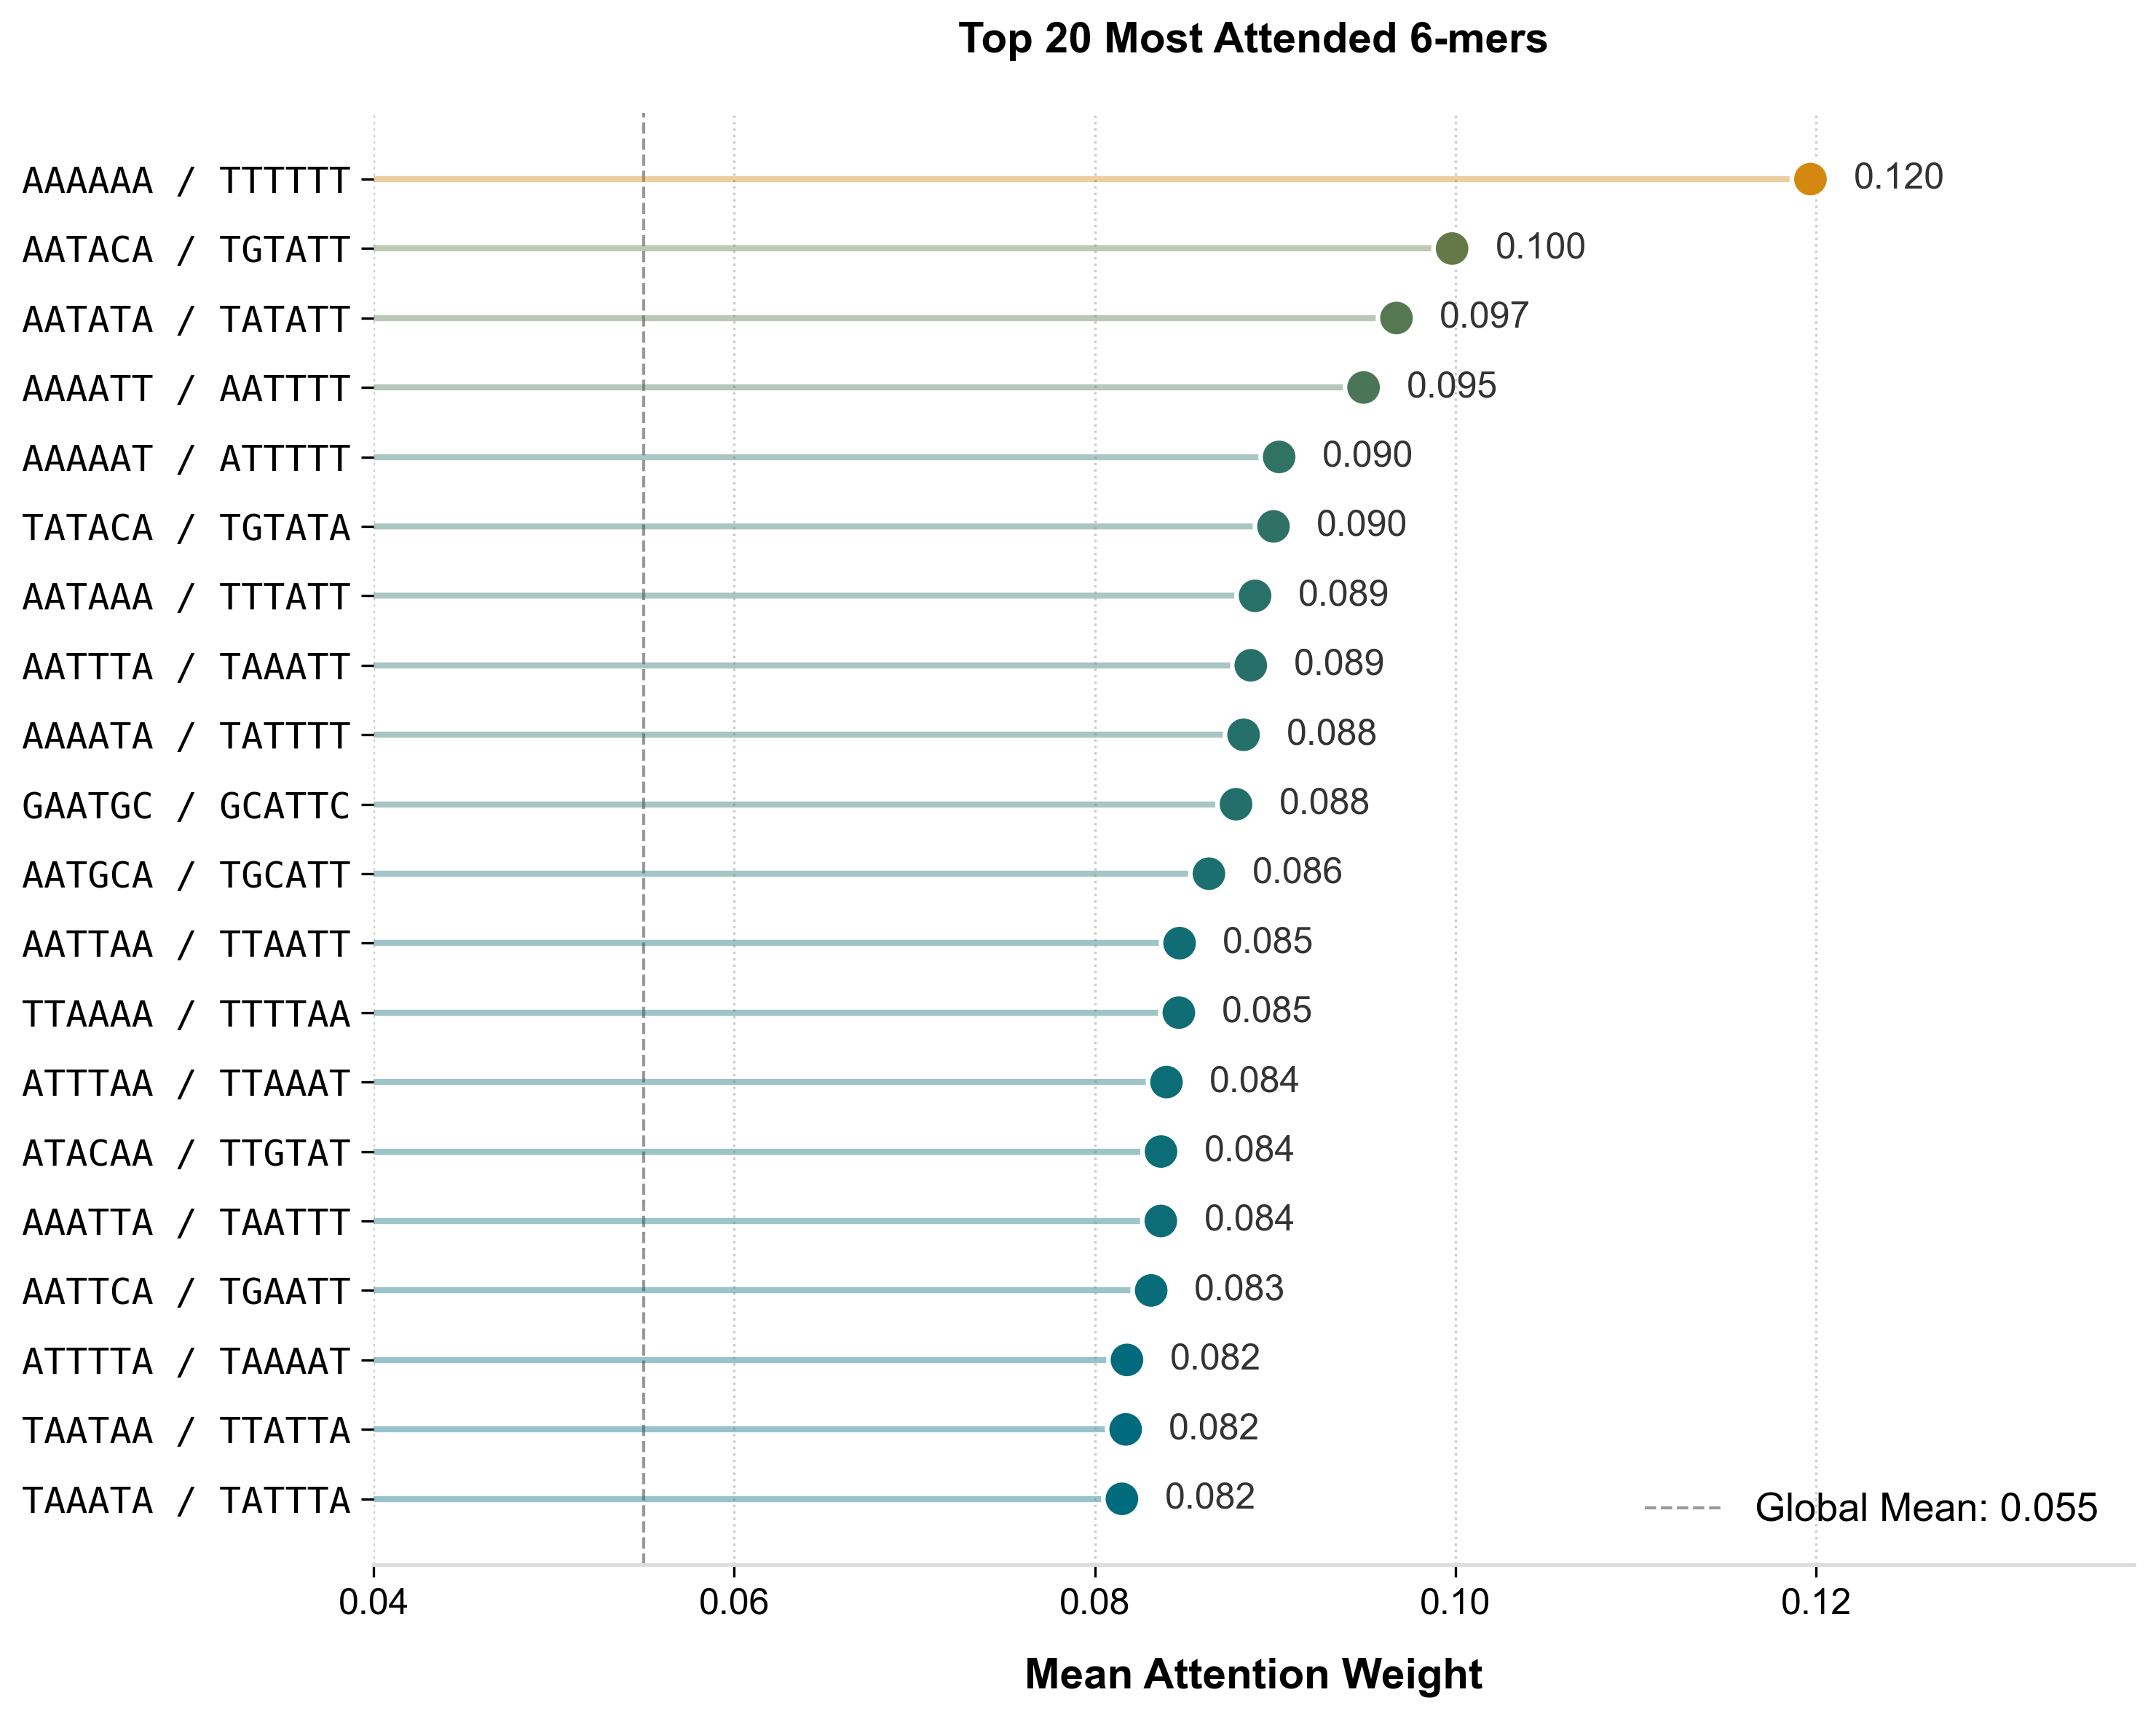

In [7]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import torch
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from Bio.Seq import Seq

# =======================================
# STILE PROFESSIONALE
# =======================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

# ----------------------
# PARAMETRI
# ----------------------
k = 6
max_tokens = 33
start_idx = 1
end_idx = 34
valid_indices = list(range(start_idx, end_idx))
topk = 20

# ----------------------
# FUNZIONE TOKENIZER
# ----------------------
def tokenize_dna_sequence(seq, k=6, max_tokens=24):
    return [seq[i:i + k] for i in range(0, k * max_tokens, k)]


attention_tensor_dir = avg_matrices_dir
attention_tensor_rc = avg_matrices_rc



# ----------------------
# 2. CALCOLO ATTENZIONE MEDIA PER TOKEN
# ----------------------

token_attention_totals = defaultdict(float)
token_counts = defaultdict(int)

for is_rc, attention_tensor in [(False, attention_tensor_dir), (True, attention_tensor_rc)]:
    for i, sample in enumerate(data_reduced):
        seq = sample['sequence']
        if is_rc:
            seq = str(Seq(seq).reverse_complement())
        
        tokens = tokenize_dna_sequence(seq, k=k, max_tokens=max_tokens)
        attn_received = attention_tensor[i][0, :]
        
        for pos_in_tensor, pos_in_token_list in enumerate(valid_indices):
            if pos_in_tensor >= len(tokens):
                break
            token = tokens[pos_in_tensor]
            attn_value = attn_received[pos_in_token_list].item()
            token_attention_totals[token] += attn_value
            token_counts[token] += 1

# ----------------------
# 3. ATTENZIONE MEDIA PER TOKEN
# ----------------------
token_mean_attention = {
    k.upper(): token_attention_totals[k] / token_counts[k]
    for k in token_attention_totals
}

# ----------------------
# 4. AGGREGAZIONE SIMMETRICA
# ----------------------
token_mean_attention_symmetric = {}
used_keys = set()

for k, v in token_mean_attention.items():
    if k in used_keys:
        continue
    k_rc = str(Seq(k).reverse_complement())
    if k_rc in token_mean_attention:
        if k != k_rc:
            key_combined = '\n'.join(sorted([k, k_rc]))
            total_score = token_mean_attention[k] + token_mean_attention[k_rc]
            used_keys.update([k, k_rc])
        else:
            key_combined = k
            total_score = token_mean_attention[k]
            used_keys.add(k)
        token_mean_attention_symmetric[key_combined] = total_score
    else:
        token_mean_attention_symmetric[k] = v
        used_keys.add(k)

# ----------------------
# 5. ORDINAMENTO
# ----------------------
sorted_items = sorted(
    token_mean_attention_symmetric.items(),
    key=lambda item: item[1],
    reverse=True
)
nomi_ordinati, score_ordinati = zip(*sorted_items)

# Calcola statistiche
mean_score = np.mean(score_ordinati)
std_score = np.std(score_ordinati)
threshold_high = mean_score + std_score


# ----------------------
# 6. PLOT: LOLLIPOP CHART ORIZZONTALE
# ----------------------
fig, ax = plt.subplots(figsize=(10, 8)) # Figura più alta per far stare le label

# Prepara i dati per il plot orizzontale
# Invertiamo l'ordine affinché il #1 sia in alto
top_n = topk
scores = np.array(score_ordinati[:top_n])[::-1]
labels = [n.replace('\n', ' / ') for n in nomi_ordinati[:top_n]][::-1] # Sostituisco \n con / per una riga sola
y_pos = range(len(labels))

# Creazione Colormap (Gradiente basato sullo score)
# Normalizziamo i colori tra il minimo e il massimo visualizzato
norm = mcolors.Normalize(vmin=min(scores), vmax=max(scores))
#cmap = plt.cm.viridis # Puoi provare anche 'plasma', 'magma' o 'coolwarm'

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# 1. Definisci i colori
color_low = '#006B7D'  # Teal
color_high = '#D4880F' # Gold/Orange

# 2. Crea la colormap
# Puoi cambiare N=256 se vuoi meno gradini (es. N=10 per colori discreti)
my_cmap = mcolors.LinearSegmentedColormap.from_list("TealToOrange", [color_low, color_high], N=256)



colors = my_cmap(norm(scores))

# 1. Disegna le linee (Stems)
ax.hlines(
    y=y_pos, 
    xmin=0, 
    xmax=scores, 
    color=colors, 
    alpha=0.4, 
    linewidth=2,
    zorder=1
)

# 2. Disegna i punti (Heads)
scatter = ax.scatter(
    scores, 
    y_pos, 
    color=colors, 
    s=150, # Dimensione del pallino
    alpha=1.0, 
    edgecolor='white',
    linewidth=1.5,
    zorder=2
)

# 3. Linea media verticale
ax.axvline(
    mean_score, 
    color='#555555', 
    linestyle='--', 
    linewidth=1, 
    alpha=0.6,
    label=f'Global Mean: {mean_score:.3f}',
    zorder=0,
)

# --- COSMETICA ---
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=12, family='monospace') # Monospace è bello per DNA
ax.set_xlabel("Mean Attention Weight", fontweight='bold', labelpad=12,fontsize=14)
ax.set_title(f"Top {topk} Most Attended 6-mers", fontweight='bold', pad=20, fontsize=14)
ax.tick_params(axis='x', labelsize=12)

# Rimuovi i bordi inutili
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) # Rimuovi asse Y verticale
ax.spines['bottom'].set_color('#DDDDDD')

# Griglia verticale leggera
ax.xaxis.grid(True, linestyle=':', alpha=0.4, color='gray')
ax.yaxis.grid(False) # Niente griglia orizzontale

# Aggiungi il valore numerico dentro o accanto al pallino
for i, (score, y) in enumerate(zip(scores, y_pos)):
    # Testo accanto al pallino
    ax.text(
        score + (max(scores)*0.02), # Leggermente a destra del pallino
        y, 
        f'{score:.3f}', 
        va='center', 
        ha='left', 
        fontsize=12, 
        color='#333333',
        fontweight='light'
    )

# Margini per far stare il testo
ax.set_xlim(0.04, max(scores) * 1.15)
ax.legend(loc='lower right', frameon=False,fontsize=13)

plt.tight_layout()

plt.savefig(f'../images/top20_most_attention6mers_{DATA_TYPE}.png', dpi=600, bbox_inches='tight')


plt.show()


🟢 Estrazione Anchors (TP)...
   -> Analizzando 58912 sequenze...


/tmp/ipykernel_610086/776461079.py:102: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  mask_tensor = torch.tensor(mask, dtype=torch.bool)


🔴 Estrazione Linkers (TN)...
   -> Analizzando 27264 sequenze...
⚪ Estrazione Background...
📊 Dataset finale: 200 Anchors | 50000 Background | 200 Linkers
--- Statistical Significance Details ---
Propeller Twist: Anchors vs Bg (p=7.4e-05) | Exclusion vs Bg (p=9.0e-22)


/tmp/ipykernel_610086/776461079.py:289: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_610086/776461079.py:323: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Nucleosome Anchoring\n Sequences (TP)', 'Global\nBackground', 'Nucleosome Exclusion\n Signals (TN)'], fontsize=15)
/tmp/ipykernel_610086/776461079.py:289: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Static Bending: Anchors vs Bg (p=1.1e-16) | Exclusion vs Bg (p=2.7e-20)
DNA Roll: Anchors vs Bg (p=9.2e-29) | Exclusion vs Bg (p=2.0e-41)


/tmp/ipykernel_610086/776461079.py:323: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Nucleosome Anchoring\n Sequences (TP)', 'Global\nBackground', 'Nucleosome Exclusion\n Signals (TN)'], fontsize=15)
/tmp/ipykernel_610086/776461079.py:289: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_610086/776461079.py:323: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Nucleosome Anchoring\n Sequences (TP)', 'Global\nBackground', 'Nucleosome Exclusion\n Signals (TN)'], fontsize=15)
/tmp/ipykernel_610086/776461079.py:289: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

Minor Groove Width: Anchors vs Bg (p=1.6e-06) | Exclusion vs Bg (p=2.3e-11)
Helical Twist: Anchors vs Bg (p=1.3e-12) | Exclusion vs Bg (p=7.8e-19)


/tmp/ipykernel_610086/776461079.py:323: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Nucleosome Anchoring\n Sequences (TP)', 'Global\nBackground', 'Nucleosome Exclusion\n Signals (TN)'], fontsize=15)
/tmp/ipykernel_610086/776461079.py:289: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_610086/776461079.py:323: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Nucleosome Anchoring\n Sequences (TP)', 'Global\nBackground', 'Nucleosome Exclusion\n Signals (TN)'], fontsize=15)
/tmp/ipykernel_610086/776461079.py:289: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

Major Groove Width: Anchors vs Bg (p=8.7e-15) | Exclusion vs Bg (p=1.3e-32)


/tmp/ipykernel_610086/776461079.py:323: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Nucleosome Anchoring\n Sequences (TP)', 'Global\nBackground', 'Nucleosome Exclusion\n Signals (TN)'], fontsize=15)


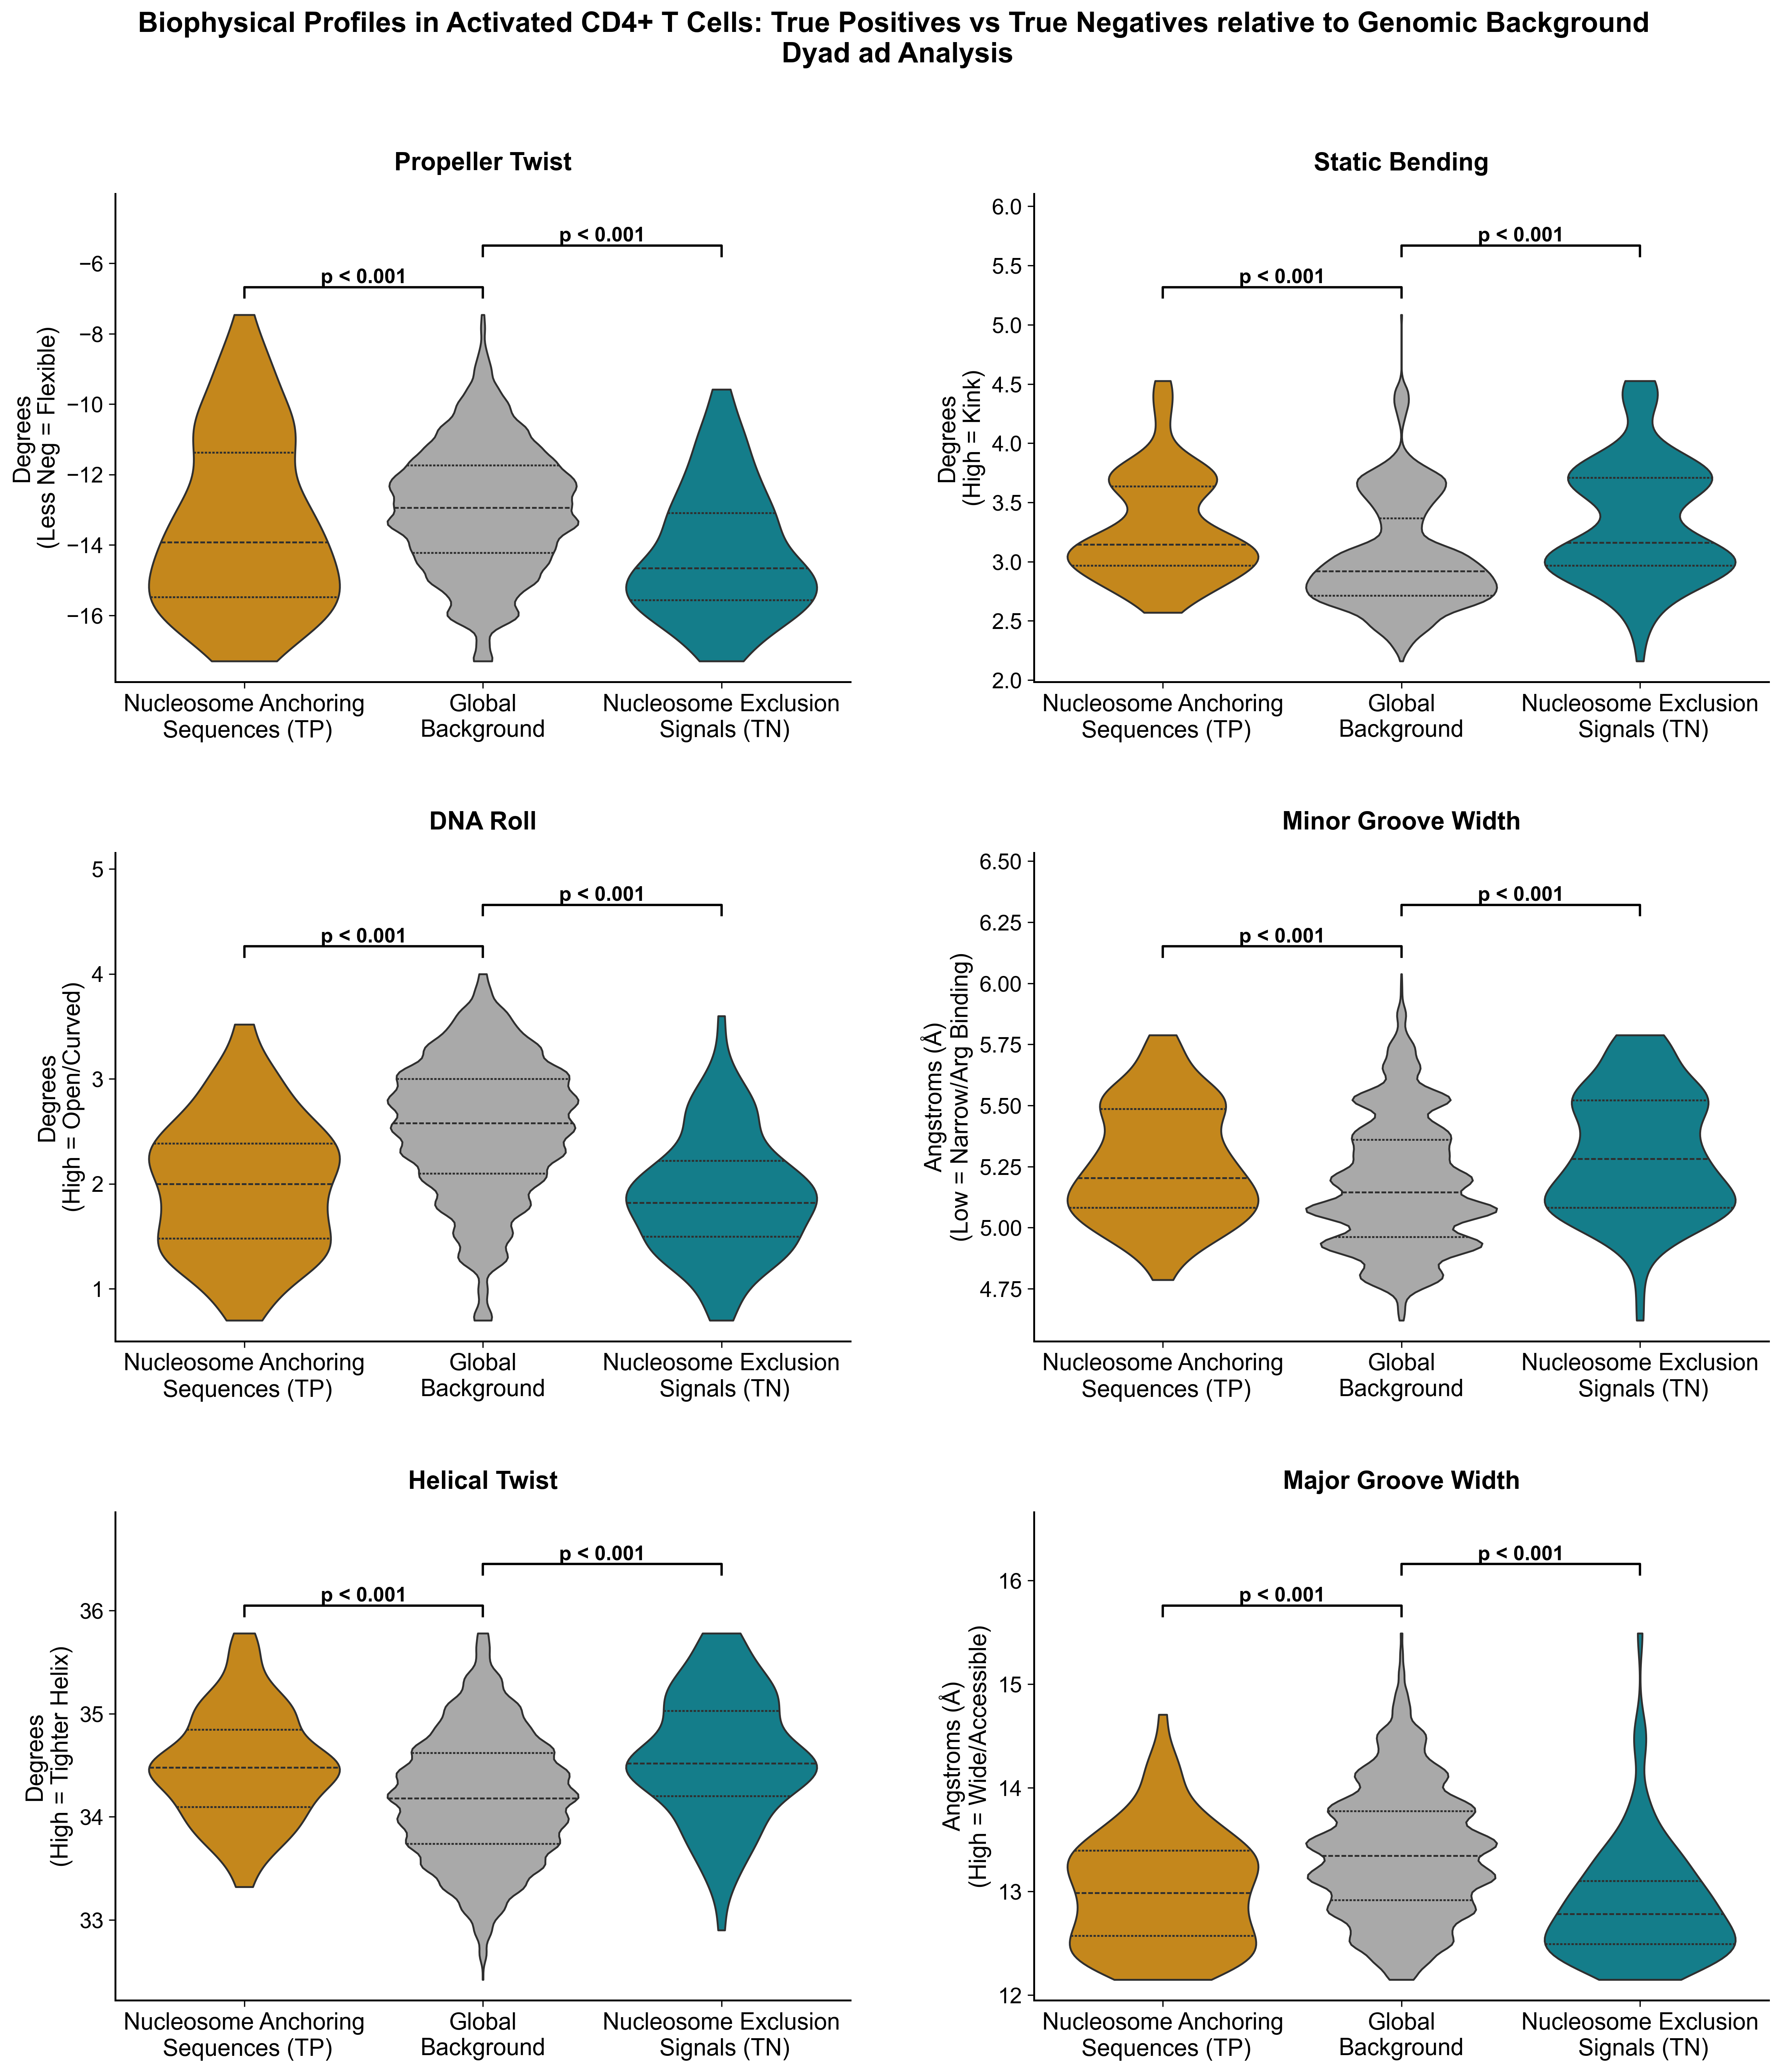

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import torch
from Bio.Seq import Seq
from collections import defaultdict
from itertools import compress
import random



DYAD = True   # <--- Metti True qui
BOUNDARY = False    # <--- False
ALL = False    # <--- False

assert DYAD + BOUNDARY + ALL == 1

if DYAD:
    DATA_LOCATION = 'Dyad'
elif BOUNDARY:
    DATA_LOCATION = 'Boundary'
elif ALL:
    DATA_LOCATION = 'Global'




# ==============================================================================
# SCALE FISICHE ESTRATTE DA: output.txt (DiProDB Export)
# ==============================================================================

# 1. PROPELLER TWIST   #CORRETTO
PROP_TWIST_DIPRO = {
    'AA': -17.3, 'AC': -6.7,  'AG': -14.3, 'AT': -16.9,
    'CA': -8.6,  'CC': -12.8, 'CG': -11.2, 'CT': -14.3,
    'GA': -15.1, 'GC': -11.7, 'GG': -12.8, 'GT': -6.7,
    'TA': -11.1, 'TC': -15.1, 'TG': -8.6,  'TT': -17.3
}

# 2. BENDABILITY (Satchwell)  #CORRETTO
BENDABILITY = {
    'AA': 3.07, 'AC': 2.97, 'AG': 2.31, 'AT': 2.60,
    'CA': 3.58, 'CC': 2.16, 'CG': 2.81, 'CT': 2.31,
    'GA': 2.51, 'GC': 3.06, 'GG': 2.16, 'GT': 2.97,
    'TA': 6.74, 'TC': 2.51, 'TG': 3.58, 'TT': 3.07
}

# 3. DNA ROLL   #CORRETTO
ROLL_DIPRO = {
    'AA': 0.7, 'AC': 0.7, 'AG': 4.5, 'AT': 1.1,
    'CA': 4.7, 'CC': 3.6, 'CG': 5.4, 'CT': 4.5,
    'GA': 1.9, 'GC': 0.3, 'GG': 3.6, 'GT': 0.7,
    'TA': 3.3, 'TC': 1.9, 'TG': 4.7, 'TT': 0.7
}

# 4. MINOR GROOVE WIDTH  #CORRETTO 
MGW = {
    'AA': 5.30, 'AC': 6.04, 'AG': 5.19, 'AT': 5.31,
    'CA': 4.79, 'CC': 4.62, 'CG': 5.16, 'CT': 5.19,
    'GA': 4.71, 'GC': 4.74, 'GG': 4.62, 'GT': 6.04,
    'TA': 6.4, 'TC': 4.71, 'TG': 4.79, 'TT': 5.30
}

# 5. HELICAL TWIST (Nuova Feature)   #CORRETTO
# Source: output.txt - Row ID 37 "Twist (DNA-protein complex)"
# Unit: Degrees. High = Tighter helix (more bp per turn).
HELICAL_TWIST = {
    'AA': 35.1, 'AC': 31.5, 'AG': 31.9, 'AT': 29.3,
    'CA': 37.3, 'CC': 32.9, 'CG': 36.1, 'CT': 31.9,
    'GA': 36.3, 'GC': 33.6, 'GG': 32.9, 'GT': 31.5,
    'TA': 37.8, 'TC': 36.3, 'TG': 37.3, 'TT': 35.1
}

# 6. MAJOR GROOVE WIDTH (Nuova Feature)  #CORRETTO
# Source: output.txt - Row ID 7 "Major Groove Width"
# Unit: Angstroms. Complementary to MGW.
MAJOR_GW = {
    'AA': 12.15, 'AC': 12.37, 'AG': 13.51, 'AT': 12.87,
    'CA': 13.58, 'CC': 15.49, 'CG': 14.42, 'CT': 13.51,
    'GA': 13.93, 'GC': 14.55, 'GG': 15.49, 'GT': 12.37,
    'TA': 12.32, 'TC': 13.93, 'TG': 13.58, 'TT': 12.15
}

def calculate_physics_complete(seq):
    seq = seq.upper()
    steps_di = [seq[i:i+2] for i in range(len(seq)-1)]
    
    return {
        'Propeller Twist': np.mean([PROP_TWIST_DIPRO.get(s, 0) for s in steps_di]),
        'Static Bending': np.mean([BENDABILITY.get(s, 0) for s in steps_di]),
        'DNA Roll': np.mean([ROLL_DIPRO.get(s, 0) for s in steps_di]),
        'Minor Groove Width': np.mean([MGW.get(s, 0) for s in steps_di]),
        'Helical Twist': np.mean([HELICAL_TWIST.get(s, 0) for s in steps_di]),
        'Major Groove Width': np.mean([MAJOR_GW.get(s, 0) for s in steps_di])
    }


def extract_top_kmers(mask, dataset, mat_dir, mat_rc, top_k=100, data_location = DATA_LOCATION):
    # 1. Filtra Dati e Matrici
    mask_tensor = torch.tensor(mask, dtype=torch.bool)
    data_filtered = list(compress(dataset, mask))
    matrices_filt_dir = mat_dir[mask_tensor]
    matrices_filt_rc = mat_rc[mask_tensor]
    
    print(f"   -> Analizzando {len(data_filtered)} sequenze...")

    # 2. Calcolo Attenzione
    token_attn = defaultdict(float)
    token_counts = defaultdict(int)
    k = 6
    
    # ---------------------------------------------------------
    # IMPOSTA QUI GLI INDICI CHE VUOI STUDIARE
    # Se vuoi studiare solo la posizione 29: valid_indices = [29]
    # Se vuoi studiare tutte le posizioni: valid_indices = list(range(1, 34))
    # ---------------------------------------------------------
    #valid_indices = [5, 29]  # Esempio per la tua richiesta specifica
    #valid_indices = list(range(1, 34)) # Usa questo per l'analisi completa
    #valid_indices = [17]#list(range(1, 34))#[17]  # Esempio per la tua richiesta specifica

    
    if data_location=='Dyad':
        valid_indices = [17]
    elif data_location=='Boundary':
        valid_indices = [5, 29]  # Esempio per la tua richiesta specifica
    elif data_location=='Global':
        valid_indices = list(range(1, 34))

    

    def quick_tokenize(seq, k=6):
        # Tokenizzazione a step di k (non sovrapposti, come nel tuo modello presumibilmente)
        return [seq[i:i + k] for i in range(0, k * 33, k)]

    for is_rc, tensor in [(False, matrices_filt_dir), (True, matrices_filt_rc)]:
        for i, sample in enumerate(data_filtered):
            seq = sample['sequence']
            if is_rc: seq = str(Seq(seq).reverse_complement())
            
            tokens = quick_tokenize(seq, k)
            
            # Prende l'attenzione del CLS (riga 0)
            attn_row = tensor[i][0, :] 
            
            # --- CORREZIONE LOGICA QUI ---
            # Iteriamo direttamente sugli indici di attenzione che ci interessano
            for attn_idx in valid_indices:
                
                # Calcoliamo l'indice corrispondente nella lista dei token.
                # Poiché attn_row[0] è [CLS], il primo token di sequenza (tokens[0]) 
                # corrisponde ad attn_row[1]. Quindi shiftiamo di -1.
                token_pos = attn_idx - 1
                
                # Controllo di sicurezza: l'indice calcolato esiste nella lista dei token?
                if 0 <= token_pos < len(tokens):
                    t = tokens[token_pos]       # Ora prendiamo il k-mer GIUSTO
                    val = attn_row[attn_idx].item() # E il valore di attenzione GIUSTO
                    
                    token_attn[t] += val
                    token_counts[t] += 1
            # -----------------------------

    # 3. Media e Simmetria (Gestione Forward + Reverse Complement)
    mean_attn = {k: token_attn[k]/token_counts[k] for k in token_attn}
    sym_attn = {}
    used = set()
    
    for k, v in mean_attn.items():
        if k in used: continue
        k_rc = str(Seq(k).reverse_complement())
        
        if k_rc in mean_attn:
            # Se esiste anche il complementare, media o somma (qui sommiamo per score totale)
            score = mean_attn[k] + mean_attn[k_rc] if k != k_rc else mean_attn[k]
            key = '\n'.join(sorted([k, k_rc]))
            used.update([k, k_rc])
        else:
            score = v
            key = k
            used.add(k)
        sym_attn[key] = score

    # 4. Ordinamento e Output
    sorted_items = sorted(sym_attn.items(), key=lambda x: x[1], reverse=True)
    top_items_raw = [i[0] for i in sorted_items[:top_k]]
    
    # Appiattisce le coppie (es. 'AAAAAA\nTTTTTT' -> ['AAAAAA', 'TTTTTT'])
    final_seqs = [seq for pair in top_items_raw for seq in pair.split('\n')]
    
    return final_seqs


# ==============================================================================
# 2. GENERAZIONE DEI 3 GRUPPI (POS, NEG, BG)
# ==============================================================================

if 'matrices_dir_all' not in locals():
    raise ValueError("ERRORE: Variabili '_all' non trovate.")

preds_int_all = (pd.read_pickle(f"preds_{DATA_TYPE}_model_sum_folds_16_02_26.pkl") > 0.5).astype(int)
val_labels_all = [sample['label'] for sample in dataset_all]

# 1. TRUE POSITIVES (Anchors)
print("🟢 Estrazione Anchors (TP)...")
mask_pos = [(p == 1 and tl == 1) for p, tl in zip(preds_int_all, val_labels_all)]
seq_pos = extract_top_kmers(mask_pos, dataset_all, matrices_dir_all, matrices_rc_all, top_k=100, data_location = DATA_LOCATION)

# 2. TRUE NEGATIVES (Linkers/Repellents)
print("🔴 Estrazione Linkers (TN)...")
mask_neg = [(p == 0 and tl == 0) for p, tl in zip(preds_int_all, val_labels_all)]
seq_neg = extract_top_kmers(mask_neg, dataset_all, matrices_dir_all, matrices_rc_all, top_k=100,data_location = DATA_LOCATION)

# 3. GLOBAL BACKGROUND
print("⚪ Estrazione Background...")
# Campioniamo sequenze per evitare tempi biblici
all_sequences = [d['sequence'] for d in dataset_all]
seq_sample = random.sample(all_sequences, 2000) if len(all_sequences) > 2000 else all_sequences
raw_bg_kmers = []
k = 6
for s in seq_sample:
    # Sliding window per avere tutto il repertorio
    raw_bg_kmers.extend([s[i:i+k] for i in range(len(s) - k + 1)])
seq_bg = random.sample(raw_bg_kmers, 50000) if len(raw_bg_kmers) > 50000 else raw_bg_kmers

print(f"📊 Dataset finale: {len(seq_pos)} Anchors | {len(seq_bg)} Background | {len(seq_neg)} Linkers")

data_plot = []
for seq in seq_pos:
    res = calculate_physics_complete(seq)
    res['Group'] = 'Nucleosome Anchors\n(True Positives)'
    data_plot.append(res)

for seq in seq_bg:
    res = calculate_physics_complete(seq)
    res['Group'] = 'Global Background'
    data_plot.append(res)

for seq in seq_neg:
    res = calculate_physics_complete(seq)
    res['Group'] = 'Nucleosome Exclusion\n(True Negatives)'
    data_plot.append(res)

df_compare = pd.DataFrame(data_plot)
order_plot = ['Nucleosome Anchors\n(True Positives)', 'Global Background', 'Nucleosome Exclusion\n(True Negatives)']

# ==============================================================================
# PLOT 3x2 (6 Pannelli)
# ==============================================================================

def annot_stat(ax, x1, x2, y, h, p_val, color='k'):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=color)
    txt = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.2e}"
    ax.text((x1+x2)*.5, y+h, txt, ha='center', va='bottom', color=color, fontsize=13, fontweight='bold')

# Aumentiamo l'altezza della figura per accomodare 3 righe
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes_flat = axes.flatten()


palette = {
    'Nucleosome Anchors\n(True Positives)': '#E08E00',#'#F59E0B',  # Vivid Amber
    'Global Background': '#A9A9A9',#'#9CA3AF',                     # Cool Grey
    'Nucleosome Exclusion\n(True Negatives)':'#008C9E',#'#06B6D4'  # Vivid Cyan/Teal
}


metrics = [
    'Propeller Twist', 'Static Bending', 
    'DNA Roll', 'Minor Groove Width',
    'Helical Twist', 'Major Groove Width' # Nuove Feature
]

ylabels = [
    "Degrees\n(Less Neg = Flexible)",       
    "Degrees\n(High = Kink)",   
    "Degrees\n(High = Open/Curved)",        
    "Angstroms (Å)\n(Low = Narrow/Arg Binding)",
    "Degrees\n(High = Tighter Helix)",       # Twist
    "Angstroms (Å)\n(High = Wide/Accessible)" # Major GW
]

print("--- Statistical Significance Details ---")

for i, metric in enumerate(metrics):
    ax = axes_flat[i]
    
    sns.violinplot(
        data=df_compare, x='Group', y=metric, order=order_plot,
        palette=palette, ax=ax, inner="quartile", cut=0, linewidth=1.2
    )

    # for line in ax.lines:
    #     line.set_color('white')
    #     # Opzionale: puoi anche forzare lo spessore o lo stile se necessario
    #     # line.set_linewidth(1.2)
    #     # line.set_alpha(1.0)
        
    # Statistica
    vals_pos = df_compare[df_compare['Group']=='Nucleosome Anchors\n(True Positives)'][metric]
    vals_bg = df_compare[df_compare['Group']=='Global Background'][metric]
    vals_neg = df_compare[df_compare['Group']=='Nucleosome Exclusion\n(True Negatives)'][metric]
    
    _, p_pos = mannwhitneyu(vals_pos, vals_bg, alternative='two-sided')
    _, p_neg = mannwhitneyu(vals_neg, vals_bg, alternative='two-sided')
    
    print(f"{metric}: Anchors vs Bg (p={p_pos:.1e}) | Exclusion vs Bg (p={p_neg:.1e})")
    
    y_max = df_compare[metric].max()
    y_range = y_max - df_compare[metric].min()
    h = y_range * 0.03
    y_line_1 = y_max + (y_range * 0.05)
    annot_stat(ax, 0, 1, y_line_1, h, p_pos)
    y_line_2 = y_line_1 + (y_range * 0.12) 
    annot_stat(ax, 1, 2, y_line_2, h, p_neg)

    ax.set_title(metric, fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel(ylabels[i], fontsize=15)
    ax.set_xlabel("")
    ax.tick_params(axis='x', labelsize=11)
    ax.set_ylim(top=y_max + (y_range * 0.35)) 
    ax.set_xticklabels(['Nucleosome Anchoring\n Sequences (TP)', 'Global\nBackground', 'Nucleosome Exclusion\n Signals (TN)'], fontsize=15)
# ==================================================================
    # MODIFICA QUI: AUMENTA DIMENSIONE NUMERI ASSE Y (e X)
    # ==================================================================
    ax.tick_params(axis='y', labelsize=14) # <--- Y AXIS NUMBERS (Grande)
    #ax.tick_params(axis='x', labelsize=12) # <--- X AXIS LABELS
    # ==================================================================
    
    
# plt.suptitle("Biophysical Profiles in Activated CD4+ T Cells: True Positives vs True Negatives relative to Genomic Background\n Boundary Analysis", 
#              fontsize=18, y=0.98, fontweight='bold')

if DATA_TYPE=='lymphoblastoid':
    plt.suptitle(f"Biophysical Profiles in Lymphoblastoid Cells: True Positives vs True Negatives relative to Genomic Background\n {DATA_LOCATION} ad Analysis", 
                 fontsize=18, y=1.02, fontweight='bold')
elif DATA_TYPE =='act':
    plt.suptitle(f"Biophysical Profiles in Activated CD4+ T Cells: True Positives vs True Negatives relative to Genomic Background\n {DATA_LOCATION} ad Analysis", 
                 fontsize=18, y=1.02, fontweight='bold')
elif DATA_TYPE=='rest':
    plt.suptitle(f"Biophysical Profiles in Resting CD4+ T Cells: True Positives vs True Negatives relative to Genomic Background\n {DATA_LOCATION} ad Analysis", 
                 fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.93, hspace=0.35, wspace=0.25)

#plt.savefig(f'../images/biophysical_profiles_{DATA_LOCATION}_{DATA_TYPE}.png', dpi=600, bbox_inches='tight')


plt.show()



In [9]:
assert False

AssertionError: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==============================================================================
# 1. DIZIONARI BIOFISICI (Completi e Corretti)
# ==============================================================================

PROP_TWIST_DIPRO = {
    'AA': -17.3, 'AC': -6.7,  'AG': -14.3, 'AT': -16.9,
    'CA': -8.6,  'CC': -12.8, 'CG': -11.2, 'CT': -14.3,
    'GA': -15.1, 'GC': -11.7, 'GG': -12.8, 'GT': -6.7,
    'TA': -11.1, 'TC': -15.1, 'TG': -8.6,  'TT': -17.3
}

BENDABILITY = {
    'AA': 3.07, 'AC': 2.97, 'AG': 2.31, 'AT': 2.60,
    'CA': 3.58, 'CC': 2.16, 'CG': 2.81, 'CT': 2.31,
    'GA': 2.51, 'GC': 3.06, 'GG': 2.16, 'GT': 2.97,
    'TA': 6.74, 'TC': 2.51, 'TG': 3.58, 'TT': 3.07
}

ROLL_DIPRO = {
    'AA': 0.7, 'AC': 0.7, 'AG': 4.5, 'AT': 1.1,
    'CA': 4.7, 'CC': 3.6, 'CG': 5.4, 'CT': 4.5,
    'GA': 1.9, 'GC': 0.3, 'GG': 3.6, 'GT': 0.7,
    'TA': 3.3, 'TC': 1.9, 'TG': 4.7, 'TT': 0.7
}

MGW = {
    'AA': 5.30, 'AC': 6.04, 'AG': 5.19, 'AT': 5.31,
    'CA': 4.79, 'CC': 4.62, 'CG': 5.16, 'CT': 5.19,
    'GA': 4.71, 'GC': 4.74, 'GG': 4.62, 'GT': 6.04,
    'TA': 6.4, 'TC': 4.71, 'TG': 4.79, 'TT': 5.30
}

HELICAL_TWIST = {
    'AA': 35.1, 'AC': 31.5, 'AG': 31.9, 'AT': 29.3,
    'CA': 37.3, 'CC': 32.9, 'CG': 36.1, 'CT': 31.9,
    'GA': 36.3, 'GC': 33.6, 'GG': 32.9, 'GT': 31.5,
    'TA': 37.8, 'TC': 36.3, 'TG': 37.3, 'TT': 35.1
}

MAJOR_GW = {
    'AA': 12.15, 'AC': 12.37, 'AG': 13.51, 'AT': 12.87,
    'CA': 13.58, 'CC': 15.49, 'CG': 14.42, 'CT': 13.51,
    'GA': 13.93, 'GC': 14.55, 'GG': 15.49, 'GT': 12.37,
    'TA': 12.32, 'TC': 13.93, 'TG': 13.58, 'TT': 12.15
}

# ==============================================================================
# 2. FUNZIONI HELPER
# ==============================================================================

def get_kmer_physics(kmer, property_dict):
    """Calcola il valore medio di una proprietà per un k-mer."""
    kmer = kmer.upper()
    if len(kmer) < 2: return 0
    steps = [kmer[i:i+2] for i in range(len(kmer)-1)]
    values = [property_dict.get(s, 0) for s in steps]
    return np.mean(values)

def plot_integrated_attention(sample_idx, dataset, matrices, k=6, highlight_pos=29):
    """
    Plotta Attenzione + 6 Profili Biofisici perfettamente allineati.
    Corregge lo shift visivo tra Barplot e Lineplot.
    """
    
    # --- A. RECUPERO DATI ---
    sample = dataset[sample_idx]
    seq = sample['sequence']
    label = sample['label']
    
    # Recupera Attention (Skip CLS + Skip ultimi 3)
    attn_values = matrices[sample_idx][0, 1:-3].numpy()
    
    # Tokenizza
    # Nota: Assumiamo che la lunghezza dei token segua quella dell'attenzione tagliata
    tokens = [seq[i:i+k] for i in range(0, k * len(attn_values), k)]
    
    # Safety Check: Tronchiamo al minimo comune
    min_len = min(len(tokens), len(attn_values))
    tokens = tokens[:min_len]
    attn_values = attn_values[:min_len]
    
    # --- B. CALCOLO FISICA PER OGNI TOKEN ---
    phys_data = {
        'Propeller Twist': [get_kmer_physics(t, PROP_TWIST_DIPRO) for t in tokens],
        'Bendability (Satchwell)': [get_kmer_physics(t, BENDABILITY) for t in tokens],
        'DNA Roll': [get_kmer_physics(t, ROLL_DIPRO) for t in tokens],
        'Minor Groove Width': [get_kmer_physics(t, MGW) for t in tokens],
        'Helical Twist': [get_kmer_physics(t, HELICAL_TWIST) for t in tokens],
        'Major Groove Width': [get_kmer_physics(t, MAJOR_GW) for t in tokens]
    }
    
    # CREAZIONE DATAFRAME
    # FIX IMPORTANTE: Usiamo range(0, len) per allineare Barplot e Lineplot
    df_plot = pd.DataFrame({
        'Plot_Index': range(len(tokens)),  # Indice numerico 0-based per allineamento
        'Token': tokens,
        'Attention': attn_values,
        **phys_data
    })

    # --- C. PLOTTING ---
    metrics = list(phys_data.keys())
    n_metrics = len(metrics)
    ratios = [3] + [1] * n_metrics
    
    # sharex=True condivide l'asse X tra tutti i subplot
    fig, axes = plt.subplots(n_metrics + 1, 1, figsize=(18, 22), sharex=True, 
                             gridspec_kw={'height_ratios': ratios, 'hspace': 0.05})
    
    # Adjust target index (highlight_pos è 1-based, qui usiamo 0-based)
    target_idx = highlight_pos - 1

    
    # 1. PLOT ATTENZIONE
    ax_attn = axes[0]
    colors = ['#006B7D'] * len(tokens)
    if 0 <= target_idx < len(tokens):
        colors[target_idx] = '#D4880F' 
    
    # Barplot usa 'Plot_Index' (0, 1, 2...)
    sns.barplot(data=df_plot, x='Plot_Index', y='Attention', palette=colors, ax=ax_attn)
    ax_attn.set_ylabel('Attention Score', fontsize=12, fontweight='bold')
    ax_attn.set_title(f"Sequence #{sample_idx} (Label: {label}) | Highlight: Pos {highlight_pos}", fontsize=15, fontweight='bold')
    
    if 0 <= target_idx < len(tokens):
        val = df_plot.iloc[target_idx]['Attention']
        ax_attn.text(target_idx, val, f"{val:.3f}", ha='center', va='bottom', color='red', fontweight='bold')

    # 2. PLOT PROPRIETÀ FISICHE
    line_colors = ['#D4880F', '#006B7D', '#800080', '#00008B', '#2E8B57', '#B22222']
    
    for i, metric in enumerate(metrics):
        ax = axes[i+1]
        
        # Lineplot usa 'Plot_Index' (0, 1, 2...) -> ORA SONO ALLINEATI
        sns.lineplot(data=df_plot, x='Plot_Index', y=metric, ax=ax, 
                     color=line_colors[i], marker='o', linewidth=2)
        
        # Linea verticale e cerchio
        if 0 <= target_idx < len(tokens):
            ax.axvline(x=target_idx, color='red', linestyle='--', alpha=0.5)
            val_phys = df_plot.iloc[target_idx][metric]
            ax.plot(target_idx, val_phys, 'ro', markersize=8)
            
            # Annotazione intelligente: alterna destra/sinistra se siamo ai bordi
            ha_pos = 'right' if target_idx > len(tokens)/2 else 'left'
            ax.text(target_idx, val_phys, f"{val_phys:.1f}", color='red', 
                    fontweight='bold', ha=ha_pos, va='bottom', fontsize=10)

        ax.set_ylabel(metric, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('') # Rimuove label X intermedi

    # 3. GESTIONE ASSE X (Solo nell'ultimo grafico)
    # Impostiamo i 6-mer come etichette
    axes[-1].set_xticks(range(len(tokens)))
    axes[-1].set_xticklabels(tokens, rotation=90, ha='center', fontfamily='monospace', fontsize=9)
    axes[-1].set_xlabel("Sequence Tokens (6-mers)", fontsize=13, fontweight='bold')
    
    # Rimuove i tick x dai grafici sopra per pulizia (opzionale, sharex lo fa già spesso)
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)

    plt.tight_layout()
    plt.show()

# ==========================================================
# ESEMPIO DI UTILIZZO
# ==========================================================
idx_to_plot = 0
found = False
for i in range(len(dataset_all)):
    if dataset_all[i]['label'] == 1: 
        idx_to_plot = i
        found = True
        break

if found:
    plot_integrated_attention(
        sample_idx=idx_to_plot, 
        dataset=dataset_all, 
        matrices=matrices_dir_all, 
        highlight_pos=17 
    )

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==============================================================================
# FUNZIONE PLOT: SOLO ATTENZIONE
# ==============================================================================

def plot_attention_only(sample_idx, dataset, matrices, k=6, highlight_pos=None):
    """
    Plotta solo l'Attenzione per un dato campione.
    Sull'asse X vengono mostrati i 6-mer corrispondenti.
    """
    
    # --- A. RECUPERO DATI ---
    sample = dataset[sample_idx]
    seq = sample['sequence']
    label = sample['label']
    
    # Recupera Attention (Logica originale: Skip CLS [0] e skip ultimi padding/SEP [-3:])
    if matrices[sample_idx].dim() > 1:
        attn_values = matrices[sample_idx][0, 1:-3].numpy()
    else:
        attn_values = matrices[sample_idx][1:-3].numpy() # Fallback se dimensioni diverse
    
    # Tokenizza la sequenza per ottenere i 6-mers
    # La logica originale assumeva token contigui non sovrapposti (stride = k)
    # tokens = [seq[0:6], seq[6:12], ...] basato sulla lunghezza dell'attenzione
    tokens = [seq[i:i+k] for i in range(0, k * len(attn_values), k)]
    
    # Safety Check: Tronchiamo al minimo comune per evitare errori di lunghezza
    min_len = min(len(tokens), len(attn_values))
    tokens = tokens[:min_len]
    attn_values = attn_values[:min_len]
    
    # CREAZIONE DATAFRAME
    df_plot = pd.DataFrame({
        'Index': range(len(tokens)),
        'Token': tokens,
        'Attention': attn_values
    })

    # --- B. PLOTTING ---
    plt.figure(figsize=(20, 8)) # Figura larga per leggere bene i 6-mer
    
    # Gestione Colori (Highlight)
    colors = ['#006B7D'] * len(tokens) # Teal di base
    
    target_idx = -1
    if highlight_pos is not None:
        target_idx = highlight_pos - 1 # Converti da 1-based a 0-based
        # if 0 <= target_idx < len(tokens):
        #     colors[target_idx] = '#D4880F' # Gold per highlight

    # Plot
    ax = sns.barplot(data=df_plot, x='Token', y='Attention', palette=colors)
    
    # # Annotazione del valore sulla barra evidenziata
    # if 0 <= target_idx < len(tokens):
    #     val = df_plot.iloc[target_idx]['Attention']
    #     ax.text(target_idx, val, f"{val:.3f}", ha='center', va='bottom', 
    #             color='#D4880F', fontweight='bold', fontsize=12)

    # Stile e Etichette
    ax.set_ylabel('Attention Score', fontsize=18, fontweight='bold')
    ax.set_xlabel('Sequence Tokens (6-mers)', fontsize=18, fontweight='bold')
    #ax.set_title(f"Sequence #{sample_idx} (Label: {label}) | Attention Profile", fontsize=16, fontweight='bold')
    
    # Rotazione etichette asse X per leggibilità
    plt.xticks(rotation=90, ha='center', fontfamily='monospace', fontsize=14)
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'../images/example_importance_cd4t_{DATA_TYPE}.png', dpi=600, bbox_inches='tight')

    
    plt.show()

# ==========================================================
# ESEMPIO DI UTILIZZO
# ==========================================================

# Trova un esempio positivo (Label 1)
idx_to_plot = 0
found = False
for i in range(len(dataset_all)):
    if dataset_all[i]['label'] == 1: 
        idx_to_plot = i
        found = True
        break

if found:
    plot_attention_only(
        sample_idx=3, 
        dataset=dataset_all, 
        matrices=matrices_dir_all, 
        highlight_pos=17  # Cambia questo numero per evidenziare una barra diversa
    )



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
from Bio import motifs
from Bio.Seq import Seq
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
from itertools import compress
import torch

# ==============================================================================
# 1. FUNZIONE ESTRAZIONE REGIONI AD ALTA ATTENZIONE (UPDATED: +/- 6 bp)
# ==============================================================================

def extract_attended_regions(mask, dataset, mat_dir, mat_rc, top_k=100, context_flank=6):
    """
    Estrae le regioni genomiche centrate sui 6-mer ad alta attenzione.
    MODIFICA: Flank aumentato a 6 bp per lato.
    Totale finestra = 6 (flank sx) + 6 (k-mer) + 6 (flank dx) = 18 bp.
    """
    # Filtra dati
    mask_tensor = torch.tensor(mask, dtype=torch.bool)
    data_filtered = list(compress(dataset, mask))
    matrices_filt_dir = mat_dir[mask_tensor]
    matrices_filt_rc = mat_rc[mask_tensor]
    
    # Lista per salvare (Score, Sequenza_Espansa)
    scored_regions = []
    
    k = 6
    # Indici di attenzione validi (1-33, saltando CLS)
    valid_indices = list(range(1, 34))

    for is_rc, tensor in [(False, matrices_filt_dir), (True, matrices_filt_rc)]:
        for i, sample in enumerate(data_filtered):
            seq = sample['sequence']
            if is_rc: seq = str(Seq(seq).reverse_complement())
            
            # Attenzione CLS
            attn_row = tensor[i][0, :]
            
            for attn_idx in valid_indices:
                score = attn_row[attn_idx].item()
                
                # Calcola posizione start nel DNA originale
                token_start = (attn_idx - 1) * k
                token_end = token_start + k
                
                # Estrai con contesto espanso (6 bp per lato)
                start_ctx = max(0, token_start - context_flank)
                end_ctx = min(len(seq), token_end + context_flank)
                
                region_seq = seq[start_ctx:end_ctx]
                
                # Teniamo solo se ha lunghezza decente (es. almeno 12bp)
                if len(region_seq) >= 12:
                    scored_regions.append((score, region_seq))
    
    # Ordina per score di attenzione e prendi i Top-K assoluti
    scored_regions.sort(key=lambda x: x[0], reverse=True)
    top_sequences = [x[1] for x in scored_regions[:top_k]]
    
    print(f"✨ Estratte {len(top_sequences)} regioni Top-Attention (Finestra ~18bp).")
    return top_sequences

# ==============================================================================
# 2. DOWNLOAD E CARICAMENTO JASPAR
# ==============================================================================

def fetch_jaspar_robust():
    """Scarica il database JASPAR 2022 Core Vertebrates."""
    filename = "JASPAR2022_CORE_vertebrates.txt"
    url = "https://jaspar.elixir.no/download/data/2024/CORE/JASPAR2024_CORE_vertebrates_non-redundant_pfms_jaspar.txt"
    
    if os.path.exists(filename):
        try:
            with open(filename, 'r') as f:
                header = f.readline()
                if header.strip().startswith("<") or len(header) < 5:
                    os.remove(filename)
                else:
                    return filename
        except:
            os.remove(filename)

    print(f"⬇️ Download JASPAR da {url}...")
    try:
        response = requests.get(url, timeout=20)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            return filename
    except Exception as e:
        print(f"❌ Errore download: {e}")
        return None

def load_motifs_safe(filename):
    print("📂 Caricamento motivi...")
    with open(filename) as handle:
        all_motifs = motifs.parse(handle, "jaspar")
    
    # Validazione
    valid = [m for m in all_motifs if m.counts is not None and len(m.counts) > 0]
    return valid

# ==============================================================================
# 3. SETUP DATI: ESTRAZIONE TOP-100 REGIONS (con Context Flank = 6)
# ==============================================================================

if 'matrices_dir_all' not in locals():
    # Placeholder
    pass 

preds_int_all = (pd.read_pickle(f"preds_{DATA_TYPE}_model_sum_folds_16_02_26.pkl") > 0.5).astype(int)
val_labels_all = [sample['label'] for sample in dataset_all]

# Maschere
mask_tp = [(p == 1 and tl == 1) for p, tl in zip(preds_int_all, val_labels_all)]
mask_tn = [(p == 0 and tl == 0) for p, tl in zip(preds_int_all, val_labels_all)]

print("🔍 Estrazione Top-100 Attended Regions per NUCLEOSOMI (TP)...")
# MODIFICA QUI: context_flank=6
seqs_pos = extract_attended_regions(mask_tp, dataset_all, matrices_dir_all, matrices_rc_all, top_k=100, context_flank=6)

print("🔍 Estrazione Top-100 Attended Regions per LINKER (TN)...")
# MODIFICA QUI: context_flank=6
seqs_neg = extract_attended_regions(mask_tn, dataset_all, matrices_dir_all, matrices_rc_all, top_k=100, context_flank=6)

# Background Reale (su queste sottosequenze specifiche)
full_text = "".join(seqs_pos + seqs_neg)
tot = len(full_text)
bg_dist = {
    'A': full_text.count('A') / tot,
    'C': full_text.count('C') / tot,
    'G': full_text.count('G') / tot,
    'T': full_text.count('T') / tot
}
print(f"📊 Background Nucleotidico Locale: {bg_dist}")

# ==============================================================================
# 4. SCANSIONE JASPAR SU REGIONI ATTENZIONATE
# ==============================================================================

jaspar_file = fetch_jaspar_robust()
motif_list = load_motifs_safe(jaspar_file)

results = []
total_pos = len(seqs_pos)
total_neg = len(seqs_neg)

print(f"\n🚀 Scansione Motivi su {total_pos} TP vs {total_neg} TN regions...")

for m in tqdm(motif_list):
    try:
        # PSSM
        m.background = bg_dist
        pwm = m.counts.normalize(pseudocounts=0.5)
        pssm = pwm.log_odds(bg_dist)
        
        # Threshold: Con sequenze di 18bp, possiamo alzare leggermente la soglia 
        # o mantenerla standard. 80% è robusto.
        threshold = pssm.max * 0.80
        
        # Scansione
        hits_pos = 0
        for seq in seqs_pos:
            # Controllo lunghezza minima per evitare errori su bordi
            if len(seq) < m.length: continue
            if max(pssm.calculate(Seq(seq))) > threshold:
                hits_pos += 1
        
        hits_neg = 0
        for seq in seqs_neg:
            if len(seq) < m.length: continue
            if max(pssm.calculate(Seq(seq))) > threshold:
                hits_neg += 1
        
        # Filtro Rumore: Ignora motivi che appaiono meno di 3 volte in totale
        if (hits_pos + hits_neg) < 3: continue

        # Statistica
        table = [[hits_pos, total_pos - hits_pos], [hits_neg, total_neg - hits_neg]]
        odds, p_val = fisher_exact(table)
        
        freq_pos = hits_pos / total_pos
        freq_neg = hits_neg / total_neg
        
        # Log2FC
        log2fc = np.log2((freq_pos + 1e-6) / (freq_neg + 1e-6))
        
        results.append({
            'ID': m.matrix_id,
            'Name': m.name,
            'Log2FC': log2fc,
            'P-value': p_val,
            'Nucleosome %': freq_pos * 100,
            'Linker %': freq_neg * 100
        })
        
    except Exception:
        continue

# DataFrame
df_res = pd.DataFrame(results)

if not df_res.empty:
    _, df_res['FDR'], _, _ = multipletests(df_res['P-value'], method='fdr_bh')
    df_res['-log10 FDR'] = -np.log10(df_res['FDR'] + 1e-100)
    df_res = df_res.sort_values('FDR')

    # ==============================================================================
    # 5. VOLCANO PLOT
    # ==============================================================================
    plt.figure(figsize=(8, 5))
    
    def get_color(row):
        if row['FDR'] > 0.05: return '#E0E0E0'
        if row['Log2FC'] > 0.5: return '#D4880F' # Gold
        if row['Log2FC'] < -0.5: return '#006B7D' # Teal
        return 'gray'
    
    colors = df_res.apply(get_color, axis=1)
    
    sns.scatterplot(data=df_res, x='Log2FC', y='-log10 FDR', c=colors, s=100, alpha=0.9, edgecolor='black')
    
    plt.axhline(-np.log10(0.05), linestyle='--', color='gray')
    plt.axvline(0.5, linestyle=':', color='gray'); plt.axvline(-0.5, linestyle=':', color='gray')
    
    # Label Top Hits
    top_hits = pd.concat([df_res[df_res['Log2FC']>0.5].head(2), df_res[df_res['Log2FC']<-0.5].head(2)])
    for _, row in top_hits.iterrows():
        plt.text(row['Log2FC'], row['-log10 FDR']+0.6, row['Name'], fontsize=9, fontweight='bold', ha='center')
    
    plt.title(f"Motif Enrichment in Top-100 Attended Regions", fontsize=14, fontweight='bold')
    plt.xlabel("Log2 Fold Change (Linker <-> Nucleosome)", fontsize=12)

    plt.savefig(f'../images/motif_enrichment_cd4t_{DATA_TYPE}.png', dpi=600, bbox_inches='tight')

    
    plt.show()
    
    print("\n--- 🏆 TOP NUCLEOSOME ATTENDED MOTIFS (18bp Window) ---")
    print(df_res[df_res['Log2FC'] > 0].head(10)[['Name', 'Log2FC', 'FDR']].to_string(index=False))
    
    print("\n--- ⛔ TOP LINKER ATTENDED MOTIFS (18bp Window) ---")
    print(df_res[df_res['Log2FC'] < 0].head(10)[['Name', 'Log2FC', 'FDR']].to_string(index=False))

else:
    print("⚠️ Nessun motivo significativo trovato.")



In [ ]:
#SE VOGLIO STUDIARE DI LATO 

import matplotlib.cm as cm
import matplotlib.colors as mcolors

import torch
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from Bio.Seq import Seq

# =======================================
# STILE PROFESSIONALE
# =======================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

# ----------------------
# PARAMETRI
# ----------------------
k = 6
max_tokens = 33
start_idx = 1
end_idx = 34
valid_indices = [5,29]#[17]#[5,29]#list(range(start_idx, end_idx))
topk = 20

# ----------------------
# FUNZIONE TOKENIZER
# ----------------------
def tokenize_dna_sequence(seq, k=6, max_tokens=24):
    return [seq[i:i + k] for i in range(0, k * max_tokens, k)]


#DATI ###


val_labels= [data['label'] for data in dataset_to_study]
preds_int=pd.read_pickle("preds_rest_model_sum_folds_16_02_26.pkl") < 0.01
data_reduced =[
    row for row, p, tl in zip(dataset_to_study, preds_int, val_labels)
    if p == tl and tl == 0
]



attention_tensor_dir = avg_matrices_dir
attention_tensor_rc = avg_matrices_rc

# ----------------------
# 2. CALCOLO ATTENZIONE MEDIA PER TOKEN
# ----------------------


token_attention_totals = defaultdict(float)
token_counts = defaultdict(int)

for is_rc, attention_tensor in [(False, attention_tensor_dir), (True, attention_tensor_rc)]:
    for i, sample in enumerate(data_reduced):
        seq = sample['sequence']
        if is_rc:
            seq = str(Seq(seq).reverse_complement())
        
        tokens = tokenize_dna_sequence(seq, k=k, max_tokens=max_tokens)
        attn_received = attention_tensor[i][0, :]
        
        for pos_in_tensor, pos_in_token_list in enumerate(valid_indices):
            if pos_in_tensor >= len(tokens):
                break
            token = tokens[pos_in_tensor]
            attn_value = attn_received[pos_in_token_list].item()
            token_attention_totals[token] += attn_value
            token_counts[token] += 1

# ----------------------
# 3. ATTENZIONE MEDIA PER TOKEN
# ----------------------
token_mean_attention = {
    k.upper(): token_attention_totals[k] / token_counts[k]
    for k in token_attention_totals
}

# ----------------------
# 4. AGGREGAZIONE SIMMETRICA
# ----------------------
token_mean_attention_symmetric = {}
used_keys = set()

for k, v in token_mean_attention.items():
    if k in used_keys:
        continue
    k_rc = str(Seq(k).reverse_complement())
    if k_rc in token_mean_attention:
        if k != k_rc:
            key_combined = '\n'.join(sorted([k, k_rc]))
            total_score = token_mean_attention[k] + token_mean_attention[k_rc]
            used_keys.update([k, k_rc])
        else:
            key_combined = k
            total_score = token_mean_attention[k]
            used_keys.add(k)
        token_mean_attention_symmetric[key_combined] = total_score
    else:
        token_mean_attention_symmetric[k] = v
        used_keys.add(k)

# ----------------------
# 5. ORDINAMENTO
# ----------------------
sorted_items = sorted(
    token_mean_attention_symmetric.items(),
    key=lambda item: item[1],
    reverse=True
)
nomi_ordinati, score_ordinati = zip(*sorted_items)

# Calcola statistiche
mean_score = np.mean(score_ordinati)
std_score = np.std(score_ordinati)
threshold_high = mean_score + std_score


# ----------------------
# 6. PLOT: LOLLIPOP CHART ORIZZONTALE
# ----------------------
fig, ax = plt.subplots(figsize=(10, 8)) # Figura più alta per far stare le label

# Prepara i dati per il plot orizzontale
# Invertiamo l'ordine affinché il #1 sia in alto
top_n = topk
scores = np.array(score_ordinati[:top_n])[::-1]
labels = [n.replace('\n', ' / ') for n in nomi_ordinati[:top_n]][::-1] # Sostituisco \n con / per una riga sola
y_pos = range(len(labels))

# Creazione Colormap (Gradiente basato sullo score)
# Normalizziamo i colori tra il minimo e il massimo visualizzato
norm = mcolors.Normalize(vmin=min(scores), vmax=max(scores))
#cmap = plt.cm.viridis # Puoi provare anche 'plasma', 'magma' o 'coolwarm'
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# 1. Definisci i colori
color_low = '#006B7D'  # Teal
color_high = '#D4880F' # Gold/Orange

# 2. Crea la colormap
# Puoi cambiare N=256 se vuoi meno gradini (es. N=10 per colori discreti)
my_cmap = mcolors.LinearSegmentedColormap.from_list("TealToOrange", [color_low, color_high], N=256)


colors = my_cmap(norm(scores))

# 1. Disegna le linee (Stems)
ax.hlines(
    y=y_pos, 
    xmin=0, 
    xmax=scores, 
    color=colors, 
    alpha=0.4, 
    linewidth=2,
    zorder=1
)

# 2. Disegna i punti (Heads)
scatter = ax.scatter(
    scores, 
    y_pos, 
    color=colors, 
    s=150, # Dimensione del pallino
    alpha=1.0, 
    edgecolor='white',
    linewidth=1.5,
    zorder=2
)

# 3. Linea media verticale
ax.axvline(
    mean_score, 
    color='#555555', 
    linestyle='--', 
    linewidth=1, 
    alpha=0.6,
    label=f'Global Mean: {mean_score:.3f}',
    zorder=0
)

# --- COSMETICA ---
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10, family='monospace') # Monospace è bello per DNA
ax.set_xlabel("Mean Attention Weight", fontweight='bold', labelpad=10)
ax.set_title(f"Top {topk} Most Attended 6-mers", fontweight='bold', pad=20, fontsize=14)

# Rimuovi i bordi inutili
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) # Rimuovi asse Y verticale
ax.spines['bottom'].set_color('#DDDDDD')

# Griglia verticale leggera
ax.xaxis.grid(True, linestyle=':', alpha=0.4, color='gray')
ax.yaxis.grid(False) # Niente griglia orizzontale

# Aggiungi il valore numerico dentro o accanto al pallino
for i, (score, y) in enumerate(zip(scores, y_pos)):
    # Testo accanto al pallino
    ax.text(
        score + (max(scores)*0.02), # Leggermente a destra del pallino
        y, 
        f'{score:.3f}', 
        va='center', 
        ha='left', 
        fontsize=9, 
        color='#333333',
        fontweight='light'
    )

# Margini per far stare il testo
ax.set_xlim(0., max(scores) * 1.15)
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
#ANALISI POSIZIONI IMPORTANTI SOTTO

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# =======================================
# STILE PROFESSIONALE
# =======================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 9,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

# =======================================
# DATI
# =======================================
TOKEN_START_IDX = 1
TOKEN_END_IDX = 34

attention_matrices_dir = avg_matrices_dir#all_matrices_dir_filtered
attention_matrices_rc = avg_matrices_rc#all_matrices_rc_filtered

try:
    attention_tensor_dir =avg_matrices_dir #torch.stack(attention_matrices_dir)
    attention_tensor_rc =avg_matrices_rc # torch.stack(attention_matrices_rc)
except (RuntimeError, TypeError):
    print("Errore: impossibile creare un tensore.")
    exit()

attention_from_cls_dir = attention_tensor_dir[:, 0, TOKEN_START_IDX:TOKEN_END_IDX]
attention_from_cls_rc = torch.flip(attention_tensor_rc[:, 0, TOKEN_START_IDX:TOKEN_END_IDX], dims=[1])
attention_from_cls = torch.cat([attention_from_cls_dir, attention_from_cls_rc], axis=0)

mean_attention = torch.mean(attention_from_cls, dim=0).cpu().numpy()
std_attention = torch.std(attention_from_cls, dim=0).cpu().numpy()
sem_attention = std_attention / np.sqrt(attention_from_cls.shape[0])

positions = np.arange(TOKEN_START_IDX, TOKEN_END_IDX)
tick_labels = [f'{(pos-1)*6}–{pos*6}' for pos in positions]

# =======================================
# BAR PLOT MIGLIORATO
# =======================================
fig, ax = plt.subplots(figsize=(10, 4))

# Colore gradiente basato sull'intensità
colors = plt.cm.viridis(mean_attention / mean_attention.max())

# In alternativa, colore uniforme elegante:
main_color = '#006B7D'
edge_color = '#004D5C'

# Barre con bordo definito
bars = ax.bar(
    positions,
    mean_attention,
    width=0.75,
    color=main_color,
    edgecolor=edge_color,
    linewidth=0.8,
    alpha=0.85,
    zorder=3
)

# Error bars discreti (SEM)
ax.errorbar(
    positions,
    mean_attention,
    yerr=sem_attention,
    fmt='none',
    ecolor='#333333',
    elinewidth=1.2,
    capsize=2.5,
    capthick=1.2,
    alpha=0.6,
    zorder=4
)

# Evidenzia le barre più importanti (opzionale)
threshold = np.percentile(mean_attention, 75)
for i, (bar, val) in enumerate(zip(bars, mean_attention)):
    if val >= threshold:
        bar.set_color('#D4880F')  # Colore accent per valori alti
        bar.set_edgecolor('#A86C0C')

# Labels
ax.set_xlabel("Sequence Position (bp)", fontweight='semibold', labelpad=10)
ax.set_ylabel("Mean Attention Weight", fontweight='semibold', labelpad=10)

# X-axis: mostra ogni etichetta ma ruotala per leggibilità
ax.set_xticks(positions[::2])
ax.set_xticklabels(tick_labels[::2], rotation=45, ha="right")
ax.set_xlim(TOKEN_START_IDX - 0.8, TOKEN_END_IDX - 0.2)

# Griglia sottile solo orizzontale
ax.grid(axis='y', linestyle='-', linewidth=0.6, alpha=0.2, color='#E0E0E0', zorder=0)

# Spines definiti
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

# Y-axis: inizia da 0 per onestà visiva
ax.set_ylim(bottom=0)

# # Aggiungi linea di riferimento media (opzionale)
# mean_global = mean_attention.mean()
# ax.axhline(
#     mean_global,
#     color='#CC3333',
#     linestyle='--',
#     linewidth=1.5,
#     alpha=0.5,
#     label=f'Overall Mean: {mean_global:.4f}',
#     zorder=2
# )

# Legenda minimale
ax.legend(
    loc='upper right',
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

plt.savefig(f'../images/position_importance_cd4t_{DATA_TYPE}.png', dpi=600, bbox_inches='tight')

plt.show()

# =======================================
# OUTPUT TESTUALE
# =======================================
print("\n" + "="*60)
print("ATTENZIONE MEDIA PER POSIZIONE")
print("="*60)
for pos, score, sem in zip(positions, mean_attention, sem_attention):
    interval = f"{(pos-1)*6}–{pos*6}"
    print(f"Pos {pos:2d} ({interval:>7} bp) → {score:.4f} ± {sem:.4f}")
print("="*60)



In [ ]:
#PROBABILMENTE SOTTO QUESTA CELLA SI PUò TOGLIERE TUTTO

In [ ]:
assert False

In [ ]:
import torch
from collections import defaultdict
import matplotlib.pyplot as plt
from Bio.Seq import Seq  # Make sure BioPython is imported for reverse_complement

# Filter for true negatives (prediction == label == 0)
def filter_true_negatives(data, preds, labels):
    return [item for item, p, tl in zip(data, preds, labels) if p == tl]# == 0]

data_reduced = dataset_to_study #filter_true_negatives(dataset_to_study, preds_int, val_labels)
all_matrices_dir_filtered = avg_matrices_dir #filter_true_negatives(all_matrices_dir, preds_int, val_labels)
all_matrices_rc_filtered = avg_matrices_rc #filter_true_negatives(all_matrices_rc, preds_int, val_labels)

# Stack filtered matrices into tensors
stacked_dir = all_matrices_dir_filtered#torch.stack(all_matrices_dir_filtered)
stacked_rc =all_matrices_rc_filtered# torch.stack(all_matrices_rc_filtered)

# Tokenize DNA sequence into non-overlapping k-mers
def tokenize_dna_sequence(seq, k=6, max_tokens=33):#24):
    return [seq[i:i+k] for i in range(0, k * max_tokens, k)]

# Compute average attention per (token, position)
def compute_attention_avg(data, attention_tensor, reverse_complement=False):
    attention_totals = defaultdict(float)
    counts = defaultdict(int)
    
    valid_indices = range(1, 34)#25)  # indices 1 to 24 (exclude CLS token 0)
    
    for i, sample in enumerate(data):
        sequence = sample['sequence']
        if reverse_complement:
            sequence = str(Seq(sequence).reverse_complement())
        
        tokens = tokenize_dna_sequence(sequence)
        attn_received = attention_tensor[i][0, :]  # Attention from CLS token
        
        for pos_in_tensor, pos_in_token_list in enumerate(valid_indices):
            token = tokens[pos_in_tensor]
            attn_value = attn_received[pos_in_token_list].item()
            key = (token, pos_in_token_list)
            
            attention_totals[key] += attn_value
            counts[key] += 1
            
    return attention_totals, counts

# Compute totals and counts for direct and reverse complement attention
totals_dir, counts_dir = compute_attention_avg(data_reduced, stacked_dir, reverse_complement=False)
totals_rc, counts_rc = compute_attention_avg(data_reduced, stacked_rc, reverse_complement=True)

# Combine totals and counts
for key, val in totals_rc.items():
    totals_dir[key] += val
    counts_dir[key] += counts_rc[key]

# Calculate mean attention per (token, position)
tokenpos_mean_attention = {
    key: totals_dir[key] / counts_dir[key] for key in totals_dir
}

# Sort descending by mean attention score
sorted_items = sorted(tokenpos_mean_attention.items(), key=lambda x: x[1], reverse=True)
tokens_positions, scores = zip(*sorted_items)
tokens_positions_str = [f"{token}, p={pos*6 - 5}-{pos*6}" for token, pos in tokens_positions]

# Plot top-k attention scores
topk = 20
plt.figure(figsize=(12, 5))
plt.bar(tokens_positions_str[:topk], scores[:topk], color='cornflowerblue')
plt.xticks(rotation=90)
plt.hlines(y=np.mean(scores), xmin = 0, xmax = topk - 1, colors='blue', linestyles='dashed',label='Distribution Mean')
plt.hlines(y=np.mean(scores)+np.std(scores), xmin=0, xmax=topk - 1, colors='lightsteelblue', linestyles='dashed', label='Distribution Mean + std')
plt.legend()



plt.title(f"Mean Attention Weight for Top {topk} 6-mer + position", fontsize=16)
plt.xlabel("6-mer + Sequence Position", fontsize=12)
plt.ylabel("Mean Attention Weight", fontsize=12)
plt.tight_layout()
plt.show()

# Print top-k textual results
print(f"\nTop {topk} 6-mer@posizione per attenzione media:")
for i in range(topk):
    print(f"{i+1:2d}. {tokens_positions_str[i]} → {scores[i]:.4f}")


In [ ]:
j=0

seq_tot = []
score_tot = []
for i,s in zip(tokens_positions_str, scores):
    j+=1
    seq = i.split(',')[0]
    pos = i.split(',')[1]
    if pos == ' p=169-174':   #169-174  97-102
        score_tot.append(s)
        seq_tot.append(seq)


In [ ]:

# ----------------------
# 6. PLOT: LOLLIPOP CHART ORIZZONTALE
# ----------------------
fig, ax = plt.subplots(figsize=(10, 8)) # Figura più alta per far stare le label

topk=10
# Prepara i dati per il plot orizzontale
# Invertiamo l'ordine affinché il #1 sia in alto
top_n = topk
scores = np.array(score_tot[:top_n])[::-1]
labels = [n.replace('\n', ' / ') for n in seq_tot[:top_n]][::-1] # Sostituisco \n con / per una riga sola
y_pos = range(len(labels))

# Creazione Colormap (Gradiente basato sullo score)
# Normalizziamo i colori tra il minimo e il massimo visualizzato
norm = mcolors.Normalize(vmin=min(scores), vmax=max(scores))
cmap = plt.cm.viridis # Puoi provare anche 'plasma', 'magma' o 'coolwarm'
colors = cmap(norm(scores))

# 1. Disegna le linee (Stems)
ax.hlines(
    y=y_pos, 
    xmin=0, 
    xmax=scores, 
    color=colors, 
    alpha=0.4, 
    linewidth=2,
    zorder=1
)

# 2. Disegna i punti (Heads)
scatter = ax.scatter(
    scores, 
    y_pos, 
    color=colors, 
    s=150, # Dimensione del pallino
    alpha=1.0, 
    edgecolor='white',
    linewidth=1.5,
    zorder=2
)

# 3. Linea media verticale
ax.axvline(
    mean_score, 
    color='#555555', 
    linestyle='--', 
    linewidth=1, 
    alpha=0.6,
    label=f'Global Mean: {mean_score:.3f}',
    zorder=0
)

# --- COSMETICA ---
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10, family='monospace') # Monospace è bello per DNA
ax.set_xlabel("Mean Attention Weight", fontweight='bold', labelpad=10)
ax.set_title(f"Top {topk} Most Attended 6-mers", fontweight='bold', pad=20, fontsize=14)

# Rimuovi i bordi inutili
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) # Rimuovi asse Y verticale
ax.spines['bottom'].set_color('#DDDDDD')

# Griglia verticale leggera
ax.xaxis.grid(True, linestyle=':', alpha=0.4, color='gray')
ax.yaxis.grid(False) # Niente griglia orizzontale

# Aggiungi il valore numerico dentro o accanto al pallino
for i, (score, y) in enumerate(zip(scores, y_pos)):
    # Testo accanto al pallino
    ax.text(
        score + (max(scores)*0.02), # Leggermente a destra del pallino
        y, 
        f'{score:.3f}', 
        va='center', 
        ha='left', 
        fontsize=9, 
        color='#333333',
        fontweight='light'
    )

# Margini per far stare il testo
ax.set_xlim(0.04, max(scores) * 1.15)
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
score_tot

In [ ]:
import pandas as pd
import logomaker
import matplotlib.pyplot as plt
import numpy as np

def plot_weighted_sequence_logo(sequences, scores, title="Sequence Importance Logo"):
    """
    Genera un Sequence Logo pesato partendo da una lista di k-mers e i loro score.
    
    Args:
        sequences (list): Lista di stringhe (es. ['ACGTAA', 'TGCATT', ...])
        scores (list): Lista di float corrispondenti ai pesi (es. attention scores)
        title (str): Titolo del grafico
    """
    
    # 1. Validazione base
    if len(sequences) != len(scores):
        raise ValueError("Le liste 'sequences' e 'scores' devono avere la stessa lunghezza.")
    
    kmer_len = len(sequences[0])
    nucleotides = ['A', 'C', 'G', 'T']
    
    # 2. Inizializzazione della Matrice (Righe=Posizioni, Colonne=Nucleotidi)
    # Creiamo un dizionario di liste inizializzate a 0.0
    matrix_data = {nt: [0.0] * kmer_len for nt in nucleotides}
    
    # 3. Accumulo dei Pesi (Weighted Decomposition)
    print("Elaborazione dei k-mers in corso...")
    
    for seq, score in zip(sequences, scores):
        # Assicuriamoci che sia maiuscolo e lungo il giusto
        seq = seq.upper()
        if len(seq) != kmer_len:
            continue # Salta sequenze anomale se ce ne sono
            
        # Per ogni posizione nel k-mer, aggiungi lo score alla base corrispondente
        for i, base in enumerate(seq):
            if base in matrix_data:
                matrix_data[base][i] += score
    
    # 4. Creazione del DataFrame Pandas (formato richiesto da Logomaker)
    df_weights = pd.DataFrame(matrix_data)
    
    # Opzionale: Normalizzazione (trasforma i pesi grezzi in frequenze/probabilità)
    # Se vuoi vedere l'intensità assoluta dell'attention, lascia così.
    # Se vuoi vedere la "probabilità" relativa, scommenta le righe sotto:
    # df_probs = df_weights.div(df_weights.sum(axis=1), axis=0)
    # logo_df = logomaker.transform_matrix(df_probs, from_type='probability', to_type='information')
    
    # Per questo esempio usiamo i pesi grezzi (Attention Mass) che è più intuitivo per "l'importanza"
    logo_df = df_weights

    # # 1. Trasforma i pesi in probabilità (normalizza affinché la somma faccia 1)
    # df_probs = df_weights.div(df_weights.sum(axis=1), axis=0)
    
    # # 2. Trasforma in Information Content (Bits)
    # # Questo calcolo automatico esalta le differenze rispetto al background (0.25)
    # logo_df = logomaker.transform_matrix(df_probs, from_type='probability', to_type='information')
    
    
    # 5. Generazione del Grafico
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Creazione del Logo
    logo = logomaker.Logo(logo_df,
                          ax=ax,
                          color_scheme='classic',  # Colori standard bioinformatica
                          vpad=.1,
                          fade_probabilities=False)

    

    # 6. Styling per il paper
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)
    
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_ylabel("Aggregate Attention Score", fontsize=12)
    ax.set_xlabel("Position in k-mer (bp)", fontsize=12)
    
    # Imposta i tick dell'asse X per mostrare 1, 2, 3, 4, 5, 6
    ax.set_xticks(range(kmer_len))
    ax.set_xticklabels(range(1, kmer_len + 1))

    plt.tight_layout()
    plt.show()
    
    return df_weights

# --- ESEMPIO DI UTILIZZO ---

# # Dati fittizi per simulare il tuo caso:
# # Immaginiamo che il modello ami i motivi ricchi di A/T all'inizio e G/C alla fine
# dummy_sequences = [
#     "AAATTT", "AAATTC", "TAATGG", "ATATGC", "GGGCCG", "CCCGGC"
# ]
# # Pesi fittizi (notare come do peso alto ai motivi AT e basso ai GC per simulare la scelta del modello)
# dummy_scores = [
#     0.95,      0.90,      0.85,      0.80,      0.10,      0.05
# ]

# Chiamata alla funzione
df_result = plot_weighted_sequence_logo(seq_tot, score_tot, 
                                        title="Weighted Motif Analysis (Entry/Exit Region)")

In [ ]:
from scipy.stats import mannwhitneyu
import numpy as np

def test_nucleotide_significance(sequences, scores, position_idx, nuc_A, nuc_B):
    """
    Confronta se c'è una differenza significativa di score tra due nucleotidi
    in una specifica posizione del k-mer.
    
    Args:
        sequences (list): Lista di stringhe 6-mer (es. ['ACGTAA', ...])
        scores (list): Lista di pesi/attention scores corrispondenti
        position_idx (int): Indice della posizione da testare (0 per la 1^ lettera, 1 per la 2^, etc.)
        nuc_A (str): Il primo nucleotide da confrontare (es. 'T')
        nuc_B (str): Il secondo nucleotide da confrontare (es. 'A')
    """
    
    # 1. Liste vuote per accumulare gli score
    scores_group_A = []
    scores_group_B = []
    
    print(f"\n--- Analisi Statistica Posizione {position_idx + 1} ---")
    print(f"Confronto: {nuc_A} vs {nuc_B}")

    # 2. Iterazione e smistamento
    for seq, score in zip(sequences, scores):
        # Controllo lunghezza per sicurezza
        if len(seq) <= position_idx:
            continue
            
        base_at_pos = seq[position_idx].upper()
        
        if base_at_pos == nuc_A:
            scores_group_A.append(score)
        elif base_at_pos == nuc_B:
            scores_group_B.append(score)

    # 3. Controllo dati sufficienti
    if len(scores_group_A) < 5 or len(scores_group_B) < 5:
        print("ERRORE: Non ci sono abbastanza dati per uno dei due gruppi.")
        return

    # 4. Calcolo delle medie (per capire chi vince 'ad occhio')
    mean_A = np.mean(scores_group_A)
    mean_B = np.mean(scores_group_B)
    
    print(f"N. campioni {nuc_A}: {len(scores_group_A)} | Media Score: {mean_A:.4f}")
    print(f"N. campioni {nuc_B}: {len(scores_group_B)} | Media Score: {mean_B:.4f}")

    # 5. Test Statistico (Mann-Whitney U)
    # alternative='two-sided' verifica se sono semplicemente "diversi"
    stat, p_value = mannwhitneyu(scores_group_A, scores_group_B, alternative='two-sided')

    # 6. Output Risultati
    print(f"P-value: {p_value:.2e}") # Notazione scientifica per numeri piccoli
    
    alpha = 0.05
    if p_value < alpha:
        print("✅ RISULTATO: La differenza è STATISTICAMENTE SIGNIFICATIVA.")
        if mean_A > mean_B:
            print(f"Il modello preferisce significativamente {nuc_A} rispetto a {nuc_B}.")
        else:
            print(f"Il modello preferisce significativamente {nuc_B} rispetto a {nuc_A}.")
    else:
        print("❌ RISULTATO: La differenza NON è significativa (potrebbe essere casuale).")

# --- ESEMPIO DI UTILIZZO ---

# Sostituisci queste liste con le tue vere liste di dati
# sequences = my_real_sequences_list
# scores = my_real_scores_list

# Esempio fittizio per farti vedere che funziona

# Nota: qui sopra ho messo score più alti quando inizia per T (0.95, 0.98) rispetto a A (0.8, 0.82)

# ESECUZIONE DEL TEST
# Testiamo la Posizione 1 (indice 0) confrontando T contro A
test_nucleotide_significance(seq_tot, score_tot, 
                             position_idx=0, 
                             nuc_A='C', 
                             nuc_B='T')

# Testiamo la Posizione 2 (indice 1) confrontando G contro C
test_nucleotide_significance(seq_tot, score_tot, position_idx=1, nuc_A='G', nuc_B='C')

In [ ]:
import requests
import numpy as np
import pandas as pd
from Bio.Seq import Seq
import time

# ==============================================================================
# 1. FUNZIONE PER SCARICARE E CALCOLARE PWM MANUALMENTE (ROBUST)
# ==============================================================================
def fetch_jaspar_pwm_manual(limit=50):
    url_list = "https://jaspar.elixir.no/api/v1/matrix/"
    params = {'tax_group': 'vertebrates', 'collection': 'CORE', 'page_size': limit}
    
    print(f"📡 Recupero lista ID da JASPAR (limit={limit})...")
    try:
        response = requests.get(url_list, params=params, timeout=10)
        response.raise_for_status()
        results = response.json()['results']
    except Exception as e:
        print(f"❌ Errore connessione iniziale: {e}")
        return []

    ready_motifs = []
    print(f"📥 Scaricamento PFM e conversione in PWM per {len(results)} motivi...")

    for i, item in enumerate(results):
        matrix_id = item['matrix_id']
        pfm_url = f"https://jaspar.elixir.no/api/v1/matrix/{matrix_id}/"
        
        try:
            # Pausa per evitare ban API (Rate Limiting)
            time.sleep(0.05) 
            r = requests.get(pfm_url, timeout=5)
            
            if r.status_code == 200:
                data = r.json()
                pfm_dict = data['pfm'] # {'A': [10, 2...], 'C': [...]}
                
                # --- CALCOLO MANUALE DELLA PWM (Log-Odds) ---
                # 1. Convertiamo in matrice numpy (4 righe: A, C, G, T)
                # Ordine fisso: A, C, G, T
                matrix_counts = np.array([
                    pfm_dict['A'],
                    pfm_dict['C'],
                    pfm_dict['G'],
                    pfm_dict['T']
                ], dtype=float)
                
                # 2. Aggiungi Pseudocounts (per evitare log(0))
                # Di solito si usa sqrt(N) o fisso 0.5/1.0. Usiamo 0.8 come standard.
                matrix_counts += 0.8
                
                # 3. Converti in Frequenze (PPM)
                # Somma delle colonne (totale conti per posizione)
                col_sums = matrix_counts.sum(axis=0)
                ppm = matrix_counts / col_sums
                
                # 4. Calcola Log-Likelihood (PWM)
                # Background standard: 0.25 per base
                background = 0.25
                pwm = np.log2(ppm / background)
                
                # Salviamo un dizionario pulito
                motif_obj = {
                    'name': data['name'],
                    'id': matrix_id,
                    'family': data.get('family', ['Unknown'])[0],
                    'pwm_matrix': pwm, # Matrice numpy 4xL
                    'length': pwm.shape[1]
                }
                ready_motifs.append(motif_obj)
            else:
                print(f"⚠️ HTTP {r.status_code} per {matrix_id}")

        except Exception as e:
            print(f"❌ Errore processando {matrix_id}: {e}")
            continue
            
    return ready_motifs

# ==============================================================================
# 2. CARICAMENTO DATI
# ==============================================================================

# Sostituisci questo con la tua lista reale di 6-mers
# Esempio fittizio per testare
# if 'seq_tot' not in locals():
#     seq_tot = ["ATATAT", "CGCCGC", "TATAAT", "GATTAC", "AAAAAA"]

# Scarica (Aumenta limit=200 quando sei sicuro che funziona)
jaspar_library = fetch_jaspar_pwm_manual(limit=500)

print(f"\n✅ Libreria caricata: {len(jaspar_library)} motivi pronti.\n")

if len(jaspar_library) == 0:
    print("STOP: Impossibile procedere senza motivi.")
    exit()

# ==============================================================================
# 3. SCORING CON SLIDING WINDOW (NumPy Ottimizzato)
# ==============================================================================
print("🔍 Calcolo Matching (Sliding Window)...")

results = []
# Map per convertire base in indice array (A=0, C=1, G=2, T=3)
base_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3, 'N': 0} 

for seq_str in seq_tot:
    k = len(seq_str) # 6
    # Converti seq in indici numerici per velocità
    try:
        seq_indices = [base_map[b] for b in seq_str]
    except KeyError:
        continue # Salta sequenze con caratteri strani
        
    for motif in jaspar_library:
        pwm = motif['pwm_matrix'] # Shape (4, L)
        pwm_len = motif['length']
        
        # SLIDING WINDOW
        # Se il motivo è più lungo del 6-mer (es. 10 vs 6)
        if pwm_len >= k:
            max_score = -9999.0
            
            # Scorri la finestra
            # pwm[:, i : i+k] prende le colonne da i a i+k
            for i in range(pwm_len - k + 1):
                # Estrai fetta della matrice
                window_matrix = pwm[:, i : i+k]
                
                # Seleziona i punteggi specifici per le basi della nostra sequenza
                # seq_indices dice quale riga prendere per ogni colonna
                score = 0
                for pos, base_idx in enumerate(seq_indices):
                    score += window_matrix[base_idx, pos]
                
                if score > max_score:
                    max_score = score
            
            # Normalizza lo score (Score medio per nucleotide)
            final_score = max_score / k
            
            # Filtro minimo per non riempire la RAM di spazzatura
            # 0.5 log-odds per base è un cutoff ragionevole per "match debole ma positivo"
            if final_score > 0.5: 
                results.append({
                    '6-mer': seq_str,
                    'TF_Name': motif['name'],
                    'ID': motif['id'],
                    'Score': final_score,
                    'Family': motif['family']
                })

# ==============================================================================
# 4. RISULTATI
# ==============================================================================
df = pd.DataFrame(results)

if not df.empty:
    print(f"\n🏆 Trovati {len(df)} matches potenziali.")
    df_sorted = df.sort_values('Score', ascending=False)
    
    print("\nTop 10 Migliori Match:")
    print(df_sorted[['6-mer', 'TF_Name', 'Score', 'ID']].head(10).to_string(index=False))
    
    # Salva
    df_sorted.to_csv("risultati_jaspar_manual.csv", index=False)
    print("\nFile 'risultati_jaspar_manual.csv' salvato.")
else:
    print("\n❌ Nessun match trovato sopra la soglia.")
    print("Suggerimento: Abbassa la soglia 'final_score > 0.5' nel codice o scarica più motivi (limit=200).")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Supponiamo che 'df' sia il DataFrame creato nel passaggio precedente
# Se lo hai chiuso, ricaricalo: df = pd.read_csv("risultati_jaspar_manual.csv")

# =========================================================
# 1. AGGREGAZIONE E PULIZIA
# =========================================================
# Teniamo solo il match con lo score più alto per ogni TF univoco
df_clean = df.sort_values('Score', ascending=False).drop_duplicates(subset=['TF_Name'])

# Raggruppiamo per Famiglia per vedere quali classi di TF sono più rappresentate
family_stats = df_clean.groupby('Family').agg({
    'Score': 'mean',          # Score medio della famiglia
    'TF_Name': 'count'        # Quanti TF diversi di quella famiglia hanno matchato
}).reset_index()

# Filtriamo solo le famiglie con almeno 2 TF o score molto alto
family_stats = family_stats[family_stats['Score'] > 1.0].sort_values('Score', ascending=False)

# =========================================================
# 2. BUBBLE PLOT DELLE FAMIGLIE
# =========================================================
plt.figure(figsize=(20, 12))

# Stile
sns.set_style("whitegrid")
norm = plt.Normalize(family_stats['Score'].min(), family_stats['Score'].max())
colors = plt.cm.viridis(norm(family_stats['Score']))

# Scatter plot
scatter = plt.scatter(
    x=family_stats['Score'],
    y=family_stats['Family'],
    s=family_stats['TF_Name'] * 100,  # La dimensione della bolla = quanti TF diversi in quella famiglia
    c=colors,
    alpha=0.8,
    edgecolor='black',
    linewidth=1
)

# Annotazioni
for i, row in family_stats.iterrows():
    plt.text(
        row['Score'] + 0.02, 
        i, 
        f"n={row['TF_Name']}", 
        va='center', 
        fontsize=9,
        color='#333'
    )

plt.title('Arricchimento per Famiglia di Fattori di Trascrizione', fontsize=15, fontweight='bold')
plt.xlabel('Mean Match Score (Log-Odds)', fontsize=12)
plt.ylabel('TF Family', fontsize=12)
plt.xlim(right=family_stats['Score'].max() + 0.2) # Spazio extra a destra

# Legenda dimensione
# Creiamo una legenda finta per spiegare le dimensioni
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6, func=lambda x: x/100)
plt.legend(handles, labels, title="N° TFs Unique Matches", loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

print("Interpretazione:")
print("- Asse X (Score): Quanto forte è il legame medio.")
print("- Dimensione Bolla: Quanti TF diversi di quella famiglia trovano match nei tuoi 6-mers.")
print("- Colore: Intensità dello score.")

In [ ]:
import pandas as pd
import numpy as np
from Bio.Seq import Seq

# ==============================================================================
# 1. DIZIONARI DI PROPRIETÀ FISICHE (Scale dinucleotidiche)
# ==============================================================================

# Scala di Flessibilità (Bendability) basata su modelli di sensibilità alla DNasi I
# Valori alti = Alta flessibilità (piace al nucleosoma)
# Valori bassi = Rigidità (respinge il nucleosoma)
# Fonte: Brukner et al., 1995 (Standard in letteratura)
BENDABILITY_SCALE = {
    'AA': -0.28, 'TT': -0.28, 'AT': -0.37, 'TA': -0.16,
    'CA': 0.04,  'TG': 0.04,  'GT': 0.04,  'AC': 0.04,
    'CT': 0.09,  'AG': 0.09,  'GA': 0.09,  'TC': 0.09,
    'GG': 0.13,  'CC': 0.13,  'GC': 0.25,  'CG': 0.13
}

# Propeller Twist (misura la distorsione dei legami idrogeno)
# Valori molto negativi (es. AA) indicano rigidità strutturale
# Fonte: El Hassan and Calladine (1996)
PROP_TWIST_SCALE = {
    'AA': -18.66, 'TT': -18.66, 'AT': -15.01, 'TA': -11.85,
    'CA': -9.49,  'TG': -9.49,  'GT': -13.48, 'AC': -13.48,
    'CT': -10.42, 'AG': -10.42, 'GA': -13.68, 'TC': -13.68,
    'GG': -8.18,  'CC': -8.18,  'GC': -10.02, 'CG': -11.08
}

# ==============================================================================
# 2. FUNZIONI DI CALCOLO
# ==============================================================================

def calculate_dna_properties(seq):
    """Calcola GC, Flessibilità media e Propeller Twist medio per un k-mer"""
    seq = seq.upper()
    length = len(seq)
    
    # 1. GC Content
    gc_count = seq.count('G') + seq.count('C')
    gc_percent = (gc_count / length) * 100
    
    # 2. Dinucleotide properties (Scorriamo la sequenza a coppie)
    bendability_scores = []
    prop_twist_scores = []
    
    # Un 6-mer ha 5 dinucleotidi (passi)
    # Es. ACGTGC -> AC, CG, GT, TG, GC
    for i in range(length - 1):
        dinuc = seq[i:i+2]
        # Se c'è una 'N' o altro char strano, saltiamo o diamo 0
        bendability_scores.append(BENDABILITY_SCALE.get(dinuc, 0))
        prop_twist_scores.append(PROP_TWIST_SCALE.get(dinuc, 0))
        
    return {
        'GC_Content': gc_percent,
        'Bendability': np.mean(bendability_scores) if bendability_scores else 0,
        'Propeller_Twist': np.mean(prop_twist_scores) if prop_twist_scores else 0,
        'Is_PolyA_T': 'AAAA' in seq or 'TTTT' in seq # Flag per tratti rigidi
    }

# ==============================================================================
# 3. ESECUZIONE SUI TUOI 6-MER
# ==============================================================================

# Esempio lista (Sostituisci con la tua lista reale appiattita)
# seq_tot = ["AAAAAA", "CCGGCG", "ATATAT", "TGACGT", "GCCCGC"]

data_structural = []

for seq in seq_tot:
    props = calculate_dna_properties(seq)
    props['6-mer'] = seq
    data_structural.append(props)

# ==============================================================================
# 4. ANALISI E CLASSIFICAZIONE
# ==============================================================================
df_struct = pd.DataFrame(data_structural)

# Classificazione Biologica Semplificata
def classify_nucleosome_potential(row):
    # Criteri euristici basati su letteratura nucleosomale
    if row['Is_PolyA_T']:
        return "Nucleosome Repellent (Rigid)"
    elif row['Bendability'] > 0.1 and row['GC_Content'] > 60:
        return "Nucleosome Favoring (Flexible/GC-rich)"
    elif row['GC_Content'] < 30:
        return "AT-rich (Likely Linker/NFR)"
    else:
        return "Neutral / Mixed"

df_struct['Potential_Role'] = df_struct.apply(classify_nucleosome_potential, axis=1)

# Ordina per Bendability (dal più flessibile al più rigido)
df_struct_sorted = df_struct.sort_values('Bendability', ascending=False)

# Output
print("="*80)
print("ANALISI STRUTTURALE (AFFINITÀ NUCLEOSOMALE)")
print("="*80)
print(df_struct_sorted[['6-mer', 'GC_Content', 'Bendability', 'Potential_Role']].head(15).to_string(index=False))

# Salva
df_struct_sorted.to_csv("analisi_strutturale_nucleosomi.csv", index=False)

In [ ]:
print('df_clean:','\n',df_clean.head(),'\n')
print('df_struct_sorted:','\n',df_struct_sorted.head())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. AGGREGAZIONE DEI DATI (IL PASSAGGIO CHIAVE)
# ==============================================================================

# Uniamo i due dataframe usando la colonna comune "6-mer".
# how='inner' assicura che teniamo solo i 6-mer che hanno SIA dati TF CHE dati strutturali.
df_merged = pd.merge(df_clean, df_struct_sorted, on="6-mer", how="inner")

# (Opzionale) Se un 6-mer ha più TF match, il merge creerà più righe con la stessa Bendability.
# Questo è corretto per il grafico: vedrai più punti sulla stessa linea verticale (stessa fisica, diversi TF).

# print(f"Match totali dopo il merge: {len(df_merged)}")
# print(df_merged.head())

# ==============================================================================
# 2. GENERAZIONE DEL GRAFICO (Physics vs Biology)
# ==============================================================================

plt.figure(figsize=(20, 12))
sns.set_style("whitegrid")

# Definiamo la hue (colore) in base al tipo.
# Se non hai creato una colonna 'Type' personalizzata, possiamo usare 'Potential_Role' 
# o creare una categoria semplice qui al volo per colorare i punti:
# Esempio: coloriamo in base alla famiglia del TF
hue_column = 'Family' 

# Scatter Plot
scatter = sns.scatterplot(
    data=df_merged, 
    x='Bendability', 
    y='Score',  # Assicurati che in df_clean la colonna si chiami 'Score' (o Score_PWM)
    hue=hue_column, 
    style='Potential_Role', # Forma diversa per ruolo nucleosomale (Opzionale)
    s=150, 
    palette='viridis', 
    edgecolor='black',
    alpha=0.8
)

# --- LINEE DI RIFERIMENTO E QUADRANTI ---
plt.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5) # Soglia alta flessibilità
plt.axhline(y=1.5, color='gray', linestyle='--', alpha=0.5) # Soglia alto score TF

# Annotazioni Quadranti (Adatta le coordinate ai tuoi dati reali)
plt.text(0.12, 1.9, "Pioneer / Nucleosome Binders?\n(High TF + Flexible)", fontsize=10, color='darkred')
plt.text(0.05, 1.9, "Classic TF Sites\n(Rigid/Linker DNA)", fontsize=10, color='darkblue')

# Etichette per i punti più estremi (Opzionale: etichetta i top 5 score)
# Ordiniamo per score e prendiamo i primi 5 per non affollare il grafico
top_points = df_merged.sort_values('Score', ascending=False).head(5)
for i, row in top_points.iterrows():
    plt.text(
        row['Bendability'] + 0.002, 
        row['Score'], 
        row['6-mer'], 
        fontsize=9,
        fontweight='bold'
    )

plt.title("Chromatin Grammar: Mechanical Properties vs Regulatory Potential", fontsize=15, fontweight='bold')
plt.xlabel("DNA Bendability (Nucleosome Affinity)", fontsize=12)
plt.ylabel("TF Binding Score (Log-Odds)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Legenda fuori dal grafico

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# ==============================================================================
# 1. FILTRAGGIO INTELLIGENTE (Top 3 TF per ogni 6-mer)
# ==============================================================================

# Assumiamo df_merged sia già creato
# df_merged = pd.merge(df_clean, df_struct_sorted, on="6-mer", how="inner")

print(f"Punti totali originali: {len(df_merged)}")

# 1. Ordina per Score decrescente (i match migliori in alto)
df_sorted = df_merged.sort_values('Score', ascending=False)

# 2. Prendi solo i primi 3 record per ogni 6-mer
df_reduced = df_sorted.groupby('6-mer').head(1)

print(f"Punti dopo riduzione (max 3 per 6-mer): {len(df_reduced)}")

# ==============================================================================
# 2. PLOT
# ==============================================================================

plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

# Plot using df_reduced
scatter = sns.scatterplot(
    data=df_reduced, 
    x='Bendability', 
    y='Score', 
    hue='Family',           
    style='Potential_Role', 
    s=150,                 
    palette='viridis',      
    edgecolor='black',      
    alpha=0.8,              
    zorder=2                
)

# Linee e Testi Quadranti (Invariati)
plt.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, zorder=1)
plt.axhline(y=1.5, color='gray', linestyle='--', alpha=0.5, zorder=1)
plt.text(0.12, 1.95, "Pioneer / Nucleosome Binders\n(High TF + Flexible)", 
         fontsize=10, color='darkred', fontweight='bold', ha='left')
plt.text(0.05, 1.95, "Classic TF Sites\n(Rigid/Linker DNA)", 
         fontsize=10, color='darkblue', fontweight='bold', ha='right')

# ==============================================================================
# 3. ETICHETTE OTTIMIZZATE
# ==============================================================================

texts = []

# TRUCCO: Per le etichette, non vogliamo scrivere "ATCCGG" 3 volte se ci sono 3 punti.
# Prendiamo solo il punto più alto (il primo di ogni gruppo) per mettere l'etichetta.
df_labels = df_reduced.groupby('6-mer').head(1)

for i, row in df_labels.iterrows():
    t = plt.text(
        row['Bendability'], 
        row['Score'], 
        row['6-mer'], 
        fontsize=9, 
        fontweight='semibold'
    )
    texts.append(t)

print("Ottimizzazione posizione etichette...")
adjust_text(
    texts, 
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_points=(1.5, 1.5) # Aumentata leggermente la repulsione
)

plt.title("Chromatin Grammar: Mechanical Properties vs Regulatory Potential", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("DNA Bendability (Nucleosome Affinity)", fontsize=13)
plt.ylabel("TF Binding Score (Log-Odds)", fontsize=13)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., title="TF Family / Role")

plt.tight_layout()
plt.show()

In [ ]:
'CCGATC',
 'GATCGG',
 'CGCGAC',
 'GTCGCG',
 'TACCGA',

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Carichiamo i dati
# Assumiamo tu abbia i due dataframe: 
# df_tf (risultati JASPAR, colonna 'Score') 
# df_struct (risultati strutturali, colonna 'Bendability')
# Se non li hai salvati, questo è un esempio di come unire i dati:

# ESEMPIO DI MERGE (Se hai salvato i CSV)
# df_tf = pd.read_csv("risultati_finali.csv")
# df_struct = pd.read_csv("analisi_strutturale_nucleosomi.csv")
# df_merged = pd.merge(df_tf, df_struct, on="6-mer", how="inner")

# --- DATI SIMULATI PER L'ESEMPIO (Usa i tuoi veri df_merged!) ---
# Creo un piccolo set di dati per farti vedere il grafico
data = {
    '6-mer': ['TGACGT', 'ACGGCG', 'AAAAAA', 'TGACTCA', 'CGAGCT', 'GCGCGC'],
    'TF_Score': [1.99, 0.2, 0.1, 1.95, 0.3, 0.1], # Score JASPAR (Alto = TF binding)
    'Bendability': [0.05, 0.136, -0.28, 0.06, 0.130, 0.140], # Alto = Nucleosoma
    'Type': ['TF-Motif', 'Nucleosome-Anchor', 'Rigid-Repellent', 'TF-Motif', 'Nucleosome-Anchor', 'Nucleosome-Anchor']
}
df_merged = pd.DataFrame(data)
# -------------------------------------------------------------

# 2. CREAZIONE DEL PLOT "PHYSICS VS BIOLOGY"
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Scatter Plot
sns.scatterplot(
    data=df_merged, 
    x='Bendability', 
    y='TF_Score', 
    hue='Type', # Se non hai la colonna Type, usa 'GC_Content' come hue
    s=150, 
    palette='viridis', 
    edgecolor='black',
    alpha=0.8
)

# 3. LINEE DI RIFERIMENTO (QUADRANTI)
plt.axvline(x=0.0, color='gray', linestyle='--', alpha=0.5) # Zero Bendability
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5) # Soglia TF Score significativo

# 4. ANNOTAZIONI DEI QUADRANTI
plt.text(0.1, 1.5, "Pioneer Factors?\n(High TF + Flexible)", fontsize=10, color='darkred', ha='center')
plt.text(-0.2, 1.5, "Classic TF Sites\n(Rigid/Linker DNA)", fontsize=10, color='darkblue', ha='center')
plt.text(0.1, 0.2, "Nucleosome Anchors\n(Structural Scaffold)", fontsize=10, color='darkgreen', ha='center')
plt.text(-0.2, 0.2, "Inert/Repellent\n(Poly-A/T)", fontsize=10, color='gray', ha='center')

# Annotiamo i nomi dei punti
for i in range(df_merged.shape[0]):
    plt.text(
        df_merged.Bendability[i]+0.005, 
        df_merged.TF_Score[i], 
        df_merged['6-mer'][i], 
        fontsize=9
    )

plt.title("Chromatin Grammar: Mechanical Properties vs Regulatory Potential", fontsize=14, fontweight='bold')
plt.xlabel("DNA Bendability (Nucleosome Affinity)", fontsize=12)
plt.ylabel("Transcription Factor Motif Score (Log-Odds)", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
'CCGATC',
 'GATCGG',
 'CGCGAC',
 'GTCGCG',
 'TACCGA',

In [ ]:
from Bio.Seq import Seq
from Bio import motifs
import pandas as pd
import numpy as np
import requests
from io import StringIO

# =============================================
# APPROCCIO SEMPLIFICATO: USA SOLO API REST
# Evita problemi con pyjaspar
# =============================================

# -----------------------------
# 1️⃣ LISTA DEI 6-MER
# -----------------------------
sequences = [Seq(s) for s in seq_tot]

# -----------------------------
# 2️⃣ PWM DAI 6-MER
# -----------------------------
m = motifs.create(sequences)
print("="*80)
print("PWM GENERATA DAL TUO SET DI 6-MER:")
print("="*80)
print(m.counts)
print()

# -----------------------------
# 3️⃣ FETCH MOTIFS DA JASPAR (API REST)
# -----------------------------
print("Caricamento motivi da JASPAR via API REST...")

def fetch_jaspar_motifs_rest(max_motifs=500):
    """Scarica motifs da JASPAR usando API REST"""
    
    # Step 1: Ottieni lista matrix IDs
    url = "https://jaspar.elixir.no/api/v1/matrix/"
    params = {
        'tax_group': 'vertebrates',
        'collection': 'CORE',
        'page_size': max_motifs
    }
    
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        matrix_list = data['results']
        print(f"✓ Trovati {len(matrix_list)} motivi JASPAR\n")
        
        return matrix_list
        
    except Exception as e:
        print(f"❌ Errore API JASPAR: {e}")
        return []

# Scarica motifs
jaspar_motifs = fetch_jaspar_motifs_rest(max_motifs=500)

if len(jaspar_motifs) == 0:
    print("❌ Impossibile scaricare motifs da JASPAR")
    print("💡 Verifica connessione internet")
    exit()

# -----------------------------
# 4️⃣ CONFRONTO 6-MER vs MOTIFS
# -----------------------------
print("Calcolo matching scores...")
results = []
skipped = 0

for seq in seq_tot:
    s = Seq(seq)
    
    for motif_info in jaspar_motifs[:200]:  # Limita a 200 per velocità
        try:
            matrix_id = motif_info['matrix_id']
            
            # Fetch PWM per questo motif
            pfm_url = f"https://jaspar.elixir.no/api/v1/matrix/{matrix_id}/"
            pfm_response = requests.get(pfm_url, timeout=5)
            
            if pfm_response.status_code != 200:
                skipped += 1
                continue
                
            pfm_data = pfm_response.json()
            pfm = pfm_data['pfm']
            
            # Lunghezza PWM
            pwm_length = len(pfm['A'])
            
            # Skippa se 6-mer più corto
            if len(s) < pwm_length:
                continue
            
            # Calcola score manuale da PFM
            # Usa log-odds semplificato
            score = 0
            bg_freq = 0.25  # Background uniforme
            
            for i, base in enumerate(str(s)[:pwm_length]):
                if base in 'ACGT' and i < pwm_length:
                    count = pfm[base][i]
                    total = sum([pfm[b][i] for b in 'ACGT'])
                    
                    if total > 0:
                        freq = (count + 1) / (total + 4)  # Pseudocount
                        score += np.log2(freq / bg_freq)
            
            # Normalizza per lunghezza
            score = score / pwm_length
            
            # Salva risultato
            results.append({
                '6-mer': seq,
                'TF_Name': pfm_data.get('name', 'Unknown'),
                'Score_PWM': score,
                'JASPAR_ID': matrix_id,
                'Class': pfm_data.get('class', 'N/A'),
                'Family': pfm_data.get('family', 'N/A'),
                'PWM_Length': pwm_length,
                'Species': pfm_data.get('species', ['N/A'])[0] if pfm_data.get('species') else 'N/A'
            })
            
        except Exception as e:
            skipped += 1
            continue
    
    # Progress indicator
    if (seq_tot.index(seq) + 1) % 5 == 0:
        print(f"  Processati {seq_tot.index(seq) + 1}/{len(seq_tot)} 6-mers...")

print(f"\n✓ Match calcolati: {len(results)}")
print(f"⚠ Match skippati: {skipped}\n")

# -----------------------------
# 5️⃣ ANALISI
# -----------------------------
if len(results) == 0:
    print("❌ NESSUN MATCH TROVATO!")
    exit()

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Score_PWM', ascending=False)

# Filtering: top 20% scores
threshold = df_results['Score_PWM'].quantile(0.80)
df_significant = df_results[df_results['Score_PWM'] >= threshold]

print("="*80)
print(f"🏆 TOP 20 MATCHES (score > {threshold:.2f})")
print("="*80)
display_cols = ['6-mer', 'TF_Name', 'Score_PWM', 'Class', 'Family', 'Species']
print(df_significant[display_cols].head(20).to_string(index=False))
print()

# -----------------------------
# 6️⃣ ANALISI PER FAMIGLIA
# -----------------------------
print("="*80)
print("📊 TOP 10 FAMIGLIE DI TF PIÙ RAPPRESENTATE")
print("="*80)
family_counts = df_significant['Family'].value_counts().head(10)
for family, count in family_counts.items():
    print(f"  {family:30s} : {count:3d} matches")
print()

# -----------------------------
# 7️⃣ ANALISI STRUTTURALE
# -----------------------------
def check_structural_motifs(seq):
    """Analisi pattern strutturali"""
    info = []
    
    # CpG
    if 'CG' in seq:
        info.append(f"CpG islands (methylation)")
    
    # GC content
    gc = (seq.count('G') + seq.count('C')) / len(seq)
    if gc >= 0.7:
        info.append(f"High GC: {gc:.0%} (promoter-like)")
    elif gc <= 0.3:
        info.append(f"Low GC: {gc:.0%} (AT-rich)")
    
    # Homopolymers
    for base in 'ACGT':
        if base * 3 in seq:
            info.append(f"{base}-repeat")
    
    # Palindrome
    if seq == str(Seq(seq).reverse_complement()):
        info.append("Palindrome")
    
    return " | ".join(info) if info else "Standard sequence"

print("="*80)
print("🔬 ANALISI STRUTTURALE TOP 10 6-MERS")
print("="*80)
for seq in df_significant['6-mer'].head(10).unique():
    print(f"{seq:8s} → {check_structural_motifs(seq)}")
print()

# -----------------------------
# 8️⃣ EXPORT
# -----------------------------
output_file = 'jaspar_results.csv'
df_significant.to_csv(output_file, index=False)
print(f"✓ Risultati salvati: {output_file}")

# -----------------------------
# 9️⃣ SUMMARY
# -----------------------------
print("\n" + "="*80)
print("📈 STATISTICHE FINALI")
print("="*80)
print(f"6-mers analizzati:        {len(seq_tot)}")
print(f"Match totali:             {len(df_results)}")
print(f"Match significativi:      {len(df_significant)}")
print(f"TF unici identificati:    {df_significant['TF_Name'].nunique()}")
print(f"Famiglie rappresentate:   {df_significant['Family'].nunique()}")
print(f"Score medio:              {df_results['Score_PWM'].mean():.3f}")
print(f"Score max:                {df_results['Score_PWM'].max():.3f}")
print("="*80)

In [ ]:
# -----------------------------
# 6️⃣ ANALISI PER FAMIGLIA
# -----------------------------
print("="*80)
print("📊 TOP 10 FAMIGLIE DI TF PIÙ RAPPRESENTATE")
print("="*80)

family_counts = df_significant['Family'].value_counts().head(10)
for family, count in family_counts.items():
    # Converti in stringa e gestisci lunghezza
    if isinstance(family, list):
        family_str = ', '.join(family)
    else:
        family_str = str(family)
    family_display = (family_str[:27] + '...') if len(family_str) > 30 else family_str
    print(f"  {family_display:<30s} : {count:3d} matches")
print()

# -----------------------------
# 7️⃣ ANALISI STRUTTURALE
# -----------------------------
def check_structural_motifs(seq):
    """Analisi pattern strutturali"""
    info = []
    
    # CpG
    if 'CG' in seq:
        info.append(f"CpG islands (methylation)")
    
    # GC content
    gc = (seq.count('G') + seq.count('C')) / len(seq)
    if gc >= 0.7:
        info.append(f"High GC: {gc:.0%} (promoter-like)")
    elif gc <= 0.3:
        info.append(f"Low GC: {gc:.0%} (AT-rich)")
    
    # Homopolymers
    for base in 'ACGT':
        if base * 3 in seq:
            info.append(f"{base}-repeat")
    
    # Palindrome
    if seq == str(Seq(seq).reverse_complement()):
        info.append("Palindrome")
    
    return " | ".join(info) if info else "Standard sequence"

print("="*80)
print("🔬 ANALISI STRUTTURALE TOP 10 6-MERS")
print("="*80)
for seq in df_significant['6-mer'].head(10).unique():
    print(f"{seq:8s} → {check_structural_motifs(seq)}")
print()

# -----------------------------
# 8️⃣ EXPORT
# -----------------------------
output_file = 'jaspar_results.csv'
df_significant.to_csv(output_file, index=False)
print(f"✓ Risultati salvati: {output_file}")

# -----------------------------
# 9️⃣ SUMMARY
# -----------------------------
print("\n" + "="*80)
print("📈 STATISTICHE FINALI")
print("="*80)
print(f"6-mers analizzati:        {len(seq_tot)}")
print(f"Match totali:             {len(df_results)}")
print(f"Match significativi:      {len(df_significant)}")
print(f"TF unici identificati:    {df_significant['TF_Name'].nunique()}")

# Gestisci Family che può essere lista
try:
    family_unique = df_significant['Family'].nunique()
except TypeError:
    # Se contiene liste, converti in stringhe
    family_unique = df_significant['Family'].apply(
        lambda x: ', '.join(x) if isinstance(x, list) else str(x)
    ).nunique()

print(f"Famiglie rappresentate:   {family_unique}")
print(f"Score medio:              {df_results['Score_PWM'].mean():.3f}")
print(f"Score max:                {df_results['Score_PWM'].max():.3f}")
print("="*80)

In [ ]:
family

In [ ]:
for i in df_significant[display_cols]['6-mer'].values[:30]:
    print(seq_tot.index(i))

In [ ]:
seq_tot.index('GATACA')

In [ ]:
sns.histplot(seq_top)

In [ ]:
import torch
from collections import defaultdict
import matplotlib.pyplot as plt
from Bio.Seq import Seq  # Assicurati di avere Biopython

# Filtra i true negatives (prediction == label == 0)
def filter_true_negatives(data, preds, labels):
    return [item for item, p, tl in zip(data, preds, labels)if p == tl == 1]

data_reduced = filter_true_negatives(dataset_to_study, preds_int, val_labels)
all_matrices_dir_filtered = filter_true_negatives(all_matrices_dir, preds_int, val_labels)
all_matrices_rc_filtered = filter_true_negatives(all_matrices_rc, preds_int, val_labels)

# Stack delle matrici in tensori
stacked_dir = torch.stack(all_matrices_dir_filtered)
stacked_rc = torch.stack(all_matrices_rc_filtered)

# Tokenizza la sequenza DNA in k-mers
def tokenize_dna_sequence(seq, k=6, max_tokens=33):#24):
    return [seq[i:i+k] for i in range(0, k * max_tokens, k)]

# # Mappa la posizione in una delle 3 regioni
# def map_position_to_region(pos):
#     if 1 <= pos <= 8:
#         return 'sinistra'
#     elif 9 <= pos <= 16:
#         return 'centrale'
#     elif 17 <= pos <= 24:
#         return 'destra'
#     else:
#         return None  # Non dovrebbe mai capitare



# Mappa la posizione in una delle 3 regioni
def map_position_to_region(pos):
    if 13 <= pos <= 20:
        return 'centrale'
    else:
        return 'laterale'


# Calcola l'attenzione media aggregata per (token, regione)
def compute_attention_avg(data, attention_tensor, reverse_complement=False):
    attention_totals = defaultdict(float)
    counts = defaultdict(int)
    
    valid_indices = range(1, 34)#25)  # da 1 a 24 (escludendo il CLS token 0)
    
    for i, sample in enumerate(data):
        sequence = sample['sequence']
        if reverse_complement:
            sequence = str(Seq(sequence).reverse_complement())
        
        tokens = tokenize_dna_sequence(sequence)
        attn_received = attention_tensor[i][0, :]  # Attenzione dal CLS token

        for pos_in_tensor, pos_in_token_list in enumerate(valid_indices):
            token = tokens[pos_in_tensor]
            attn_value = attn_received[pos_in_token_list].item()
            region = map_position_to_region(pos_in_token_list)
            key = (token, region)
            
            attention_totals[key] += attn_value
            counts[key] += 1
            
    return attention_totals, counts

# Calcola totali e conteggi
totals_dir, counts_dir = compute_attention_avg(data_reduced, stacked_dir, reverse_complement=False)
totals_rc, counts_rc = compute_attention_avg(data_reduced, stacked_rc, reverse_complement=True)

# Somma le attenzioni dirette e reverse complement
for key, val in totals_rc.items():
    totals_dir[key] += val
    counts_dir[key] += counts_rc[key]

# Calcola attenzione media
token_region_mean_attention = {
    key: totals_dir[key] / counts_dir[key] for key in totals_dir
}

# Ordina in base all'attenzione media decrescente
sorted_items = sorted(token_region_mean_attention.items(), key=lambda x: x[1], reverse=True)
tokens_regions, scores = zip(*sorted_items)
tokens_regions_str = [f"{token}@{region}" for token, region in tokens_regions]

# Plot
topk = 50
plt.figure(figsize=(12, 5))
plt.bar(tokens_regions_str[:topk], scores[:topk], color='cornflowerblue')
plt.xticks(rotation=90)
plt.title(f"Top {topk} 6-mer@regione per attenzione media")
plt.xlabel("6-mer@regione")
plt.ylabel("Attenzione media ricevuta")
plt.tight_layout()
plt.show()

# Stampa testuale
print(f"\nTop {topk} 6-mer@regione per attenzione media:")
for i in range(topk):
    print(f"{i+1:2d}. {tokens_regions_str[i]} → {scores[i]:.4f}")

for i in range(topk):
    print(f"{i+1:2d}. {tokens_regions_str[i]} → {scores[i]:.4f}")


In [ ]:
data_reduced[0]

In [ ]:
#GEMINI --------------------

import torch
from collections import defaultdict
import matplotlib.pyplot as plt

# VERSIONE (TOKEN, POSIZIONE)
# 7. Filtro per veri negativi
data_reduced = [
    row for row, p, tl in zip(dataset_to_study, preds_int, val_labels)
    if p == tl and tl == 1
][2:]

all_matrices_dir_filtered = [
    m for m, p, tl in zip(all_matrices_dir, preds_int, val_labels)
    if p == tl and tl == 1
][2:]
all_matrices_rc_filtered = [
    m for m, p, tl in zip(all_matrices_rc, preds_int, val_labels)
    if p == tl and tl == 1
][2:]


stacked_dir = torch.stack(all_matrices_dir_filtered)
stacked_rc = torch.stack(all_matrices_rc_filtered)

lista_dizionari = [data_reduced[1]]
attention_tensor_dir = [stacked_dir[1]]
attention_tensor_rc = [stacked_rc[1]]


def tokenize_dna_sequence(seq, k=6, max_tokens=33):#24):
    """Tokenizza una sequenza di DNA in k-mer non sovrapposti."""
    return [seq[i:i+k] for i in range(0, k*max_tokens, k)]

# Indici validi nel tensore di attenzione (escludendo CLS, EOS, etc.)
start_idx = 1
end_idx = 34#25
valid_indices = list(range(start_idx, end_idx))  # da 1 a 24

# Dizionari per accumulare i valori
tokenpos_attention_totals = defaultdict(float)
tokenpos_counts = defaultdict(int)

# 8. Calcolo dell'attenzione media per ogni (token, posizione)
for i, sample in enumerate(lista_dizionari):
    sequence = sample['sequence']
    tokens = tokenize_dna_sequence(sequence)  # 24 token
    # Attenzione ricevuta dal token CLS (indice 0) verso tutti gli altri token
    attn_received = attention_tensor_dir[i][0, :] # Forma (28,)

    for pos_in_tensor, pos_in_token_list in enumerate(valid_indices):
        token = tokens[pos_in_tensor]
        attn_value = attn_received[pos_in_token_list].item()
        key = (token, pos_in_token_list) # La chiave ora è (token, posizione assoluta nel tensore)
        
        tokenpos_attention_totals[key] += attn_value
        tokenpos_counts[key] += 1


# # 8. Calcolo dell'attenzione media per ogni (token, posizione)
# for i, sample in enumerate(lista_dizionari):
#     sequence = str(Seq(sample['sequence']).reverse_complement())
#     tokens = tokenize_dna_sequence(sequence)  # 24 token
#     # Attenzione ricevuta dal token CLS (indice 0) verso tutti gli altri token
#     attn_received = attention_tensor_rc[i][0, :] # Forma (28,)

#     for pos_in_tensor, pos_in_token_list in enumerate(valid_indices):
#         token = tokens[pos_in_tensor]
#         attn_value = attn_received[pos_in_token_list].item()
#         key = (token, pos_in_token_list) # La chiave ora è (token, posizione assoluta nel tensore)
        
#         tokenpos_attention_totals[key] += attn_value
#         tokenpos_counts[key] += 1
        

# Calcola l'attenzione media
tokenpos_mean_attention = {
    k: tokenpos_attention_totals[k] / tokenpos_counts[k]
    for k in tokenpos_attention_totals
}

# 9. Ordina i risultati per score decrescente
# Si ordina direttamente dal dizionario delle medie, senza fusione con RC
sorted_items = sorted(tokenpos_mean_attention.items(), key=lambda x: x[1], reverse=True)
nomi_ordinati_pos, score_ordinati = zip(*sorted_items)

# Formatta i nomi come "token@posizione" per il grafico
nomi_ordinati_str = [f"{tok}@{pos}" for tok, pos in nomi_ordinati_pos]

# 10. Visualizza i risultati
topk = 24
plt.figure(figsize=(12, 5))
plt.bar(nomi_ordinati_str[:topk], score_ordinati[:topk], color='cornflowerblue')
plt.xticks(rotation=90)
plt.title(f"Top {topk} 6-mer@posizione per attenzione media")
plt.xlabel("6-mer@posizione")
plt.ylabel("Attenzione media ricevuta")
plt.tight_layout()
plt.show()

# 11. Stampa i risultati testuali
print(f"\nTop {topk} 6-mer@posizione per attenzione media:")
for i in range(topk):
    print(f"{i+1:2d}. {nomi_ordinati_str[i]} → {score_ordinati[i]:.4f}")

In [ ]:
# # -------------------------------
# # 3. Uso di DeepLiftSHAP
# # -------------------------------
# # Creiamo un interprete DeepLiftShap
# dl_shap = DeepLiftShap(model)

# # Input da spiegare (nuovi dati)
# inputs = data_reduced

# # Scelta delle baseline: tipicamente 0 o input medi
# baselines = data_reduced*0

# # Calcolo delle attribuzioni
# attributions = dl_shap.attribute(inputs, baselines=baselines)

# print("Input:\n", inputs)
# print("Attribuzioni DeepLiftSHAP:\n", attributions)


In [ ]:
import matplotlib.pyplot as plt

# Supponiamo che tokenpos_mean_attention sia già definito
# È un dizionario tipo: {('TGGTAG', 1): 0.025, ...}


positions = [p for (kmer, p) in tokenpos_mean_attention.keys()]
values = [v for (kmer, p), v in tokenpos_mean_attention.items()]
kmers = [kmer.upper() for (kmer, p) in tokenpos_mean_attention.keys()]

# Calcolo font size dinamico
min_size = 8
max_size = 20
min_v = min(values)
max_v = max(values)
norm = lambda v: min_size + (v - min_v) / (max_v - min_v + 1e-8) * (max_size - min_size)

# Plot
plt.figure(figsize=(15, 8))
plt.bar(positions, values, color='cornflowerblue')

# Etichette con dimensione in base a valore
for x, y, kmer in zip(positions, values, kmers):
    plt.text(x, y + 0.001, kmer, ha='center', va='bottom', fontsize=norm(y), rotation=0)

plt.xlabel("Token position")
plt.title("Example of single seqence sequence analysis")
plt.ylabel("Attention Weight", fontsize=12)
plt.xticks(positions)  # Assicura che tutte le posizioni siano mostrate
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dati

# Normalizzazione font size
min_size = 8
max_size = 28
min_val = min(values)
max_val = max(values)
scale = lambda v: min_size + (v - min_val) / (max_val - min_val + 1e-8) * (max_size - min_size)

# Plot
plt.figure(figsize=(len(kmers) * 1.2, 2))
x_pos = 0  # posizione orizzontale cumulativa

for kmer, val in zip(kmers, values):
    fs = scale(val)
    plt.text(x_pos, 0, kmer, fontsize=fs, ha='left', va='center', family='monospace')
    # Avanza la posizione: più grande è il font, più spazio serve
    x_pos += len(kmer) * (fs * 0.001)  # tweak questo coefficiente per densità

plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import copy

dataset = copy.deepcopy([i for i in dataset_sapiens])
# 1. Filtra dataset con sequenze lunghezza 28
#dataset = [i for i in dataset_sapiens].copy() #if i['embedding'].shape[0] == 28]

# 2. Seleziona dati di test
dataset_test_to_study = [dataset[i] for i in internal_val_idx].copy()  # Assicurati che gli indici siano corretti


for i in range(len(dataset_test_to_study)):
    dataset_test_to_study[i]['embedding'][6:7,:]=0
    dataset_test_to_study[i]['embedding_rev'][18:19,:]=0
    
# 3. Crea dataloader
test = Nuc_Dataset(dataset_test_to_study, dim_embedding)
test = DataLoader(test, batch_size=64, shuffle=False)

# 4. Inference
metrics, val_labels, val_preds, importance, importance_rc = test_classification(model_internal, test)

# 5. Preds binarie
preds_int = [p > 0.5 for p in val_preds]

# 6. Estrai matrici direzionali
all_matrices_dir = [m for batch in importance for m in batch]  # importance = [B, 28, 28]
all_matrices_rc = [m for batch in importance_rc for m in batch]

all_matrices_tot = all_matrices_dir + all_matrices_rc#[x + invert_attention(y) for x,y in zip(all_matrices_dir,all_matrices_rc)]

preds_int = preds_int + preds_int

dataset_test_to_study *= 2

# 7. Etichette originali
true_label = val_labels + val_labels

# 8. Filtro per veri negativi
all_matrices_tot_filtered = [
    m for m, p, tl in zip(all_matrices_tot, preds_int, true_label)
    #if p == 0 and tl == 0 and m.shape == (28, 28)
]

# 9. Calcolo media e visualizzazione
if len(all_matrices_tot_filtered) > 0:
    stacked = torch.stack(all_matrices_tot_filtered)
    media = stacked[:,0,:].mean(dim=0).unsqueeze(0)
    media_norm = (media - media.min()) / (media.max() - media.min() + 1e-8)

    plt.figure(figsize=(6, 5))
    sns.heatmap(media_norm.cpu().numpy(), cmap="viridis")
    plt.title("Heatmap normalizzata - Veri negativi (p=0, tl=0)")
    plt.show()
else:
    print("⚠️ Nessun vero negativo trovato con shape [28, 28].")


In [ ]:
val_preds#0.00065244175

# [0.99641716,
#  0.9750645,
#  0.016087318,
#  0.8559031,
#  0.89552456,
#  0.018351797,
#  0.0070057027,
#  0.0021655096,
#  0.019678038,
#  0.7941537,
#  0.9603779,
#  0.0006276016,

In [ ]:
#FINEEEEEEEEEEE

In [ ]:
# #VERSIONE (TOKEN,POSIZIONE)
# data_reduced = [
#     row for row, p, tl in zip(dataset_test_to_study, preds_int, val_labels)
#     if p == tl and tl == 0 #if p == 0 and tl == 0
# ]


# # 8. Filtro per veri negativi
# all_matrices_tot_filtered = [
#     m for m, p, tl in zip(all_matrices_tot, preds_int, val_labels)
#     if p == tl and tl == 0 #if p == 0 and tl == 0 and m.shape == (28, 28)
# ]
# stacked = torch.stack(all_matrices_tot_filtered)

# lista_dizionari = [data_reduced[0]]
# attention_tensor = [stacked[0]]

# def tokenize_dna_sequence(seq, k=6, max_tokens=24):
#     return [seq[i:i+k] for i in range(0, k*max_tokens, k)]

# start_idx = 1
# end_idx = 25
# valid_indices = list(range(start_idx, end_idx))  # 1..24

# tokenpos_attention_totals = defaultdict(float)
# tokenpos_counts = defaultdict(int)

# for i, sample in enumerate(lista_dizionari):
#     sequence = sample['sequence']
#     tokens = tokenize_dna_sequence(sequence)  # 24 token
#     attn_received = attention_tensor[i][0,:]   #.sum(dim=0)  # shape (28,)

#     for pos_in_tensor, pos_in_token in enumerate(valid_indices):
#         token = tokens[pos_in_tensor]
#         attn_value = attn_received[pos_in_token].item()
#         key = (token, pos_in_token)
#         tokenpos_attention_totals[key] += attn_value
#         tokenpos_counts[key] += 1

# # Calcola attenzione media per (token, posizione)
# tokenpos_mean_attention = {
#     k: tokenpos_attention_totals[k] / tokenpos_counts[k]
#     for k in tokenpos_attention_totals
# }

# # Combina simmetricamente: (token, pos) ↔ (RC(token), 23 - pos)
# merged_symmetric_scores = {}

# for (token, pos), score in tokenpos_mean_attention.items():
#     rc = str(Seq(token).reverse_complement())
#     sym_pos = 23 - pos
#     # Canonical key: ordina tra le due coppie simmetriche
#     key1 = (token, pos)
#     key2 = (rc, sym_pos)
#     canonical_key = min(key1, key2)
#     merged_symmetric_scores[canonical_key] = merged_symmetric_scores.get(canonical_key, 0) + score

# # Ordina per score decrescente
# nomi_ordinati_pos, score_ordinati = zip(*sorted(merged_symmetric_scores.items(), key=lambda x: x[1], reverse=True))

# # Formatta nome token@posizione
# nomi_ordinati_str = [f"{tok}@{pos}" for tok, pos in nomi_ordinati_pos]

# # Visualizza i top token+pos più importanti
# topk = 24
# plt.figure(figsize=(12, 5))
# plt.bar(nomi_ordinati_str[:topk], score_ordinati[:topk], color='salmon')
# plt.xticks(rotation=90)
# plt.title(f"Top {topk} 6-mer@position (con simmetria RC + pos) per attenzione media")
# plt.xlabel("6-mer@position (canonical pair)")
# plt.ylabel("Attenzione media ricevuta")
# plt.tight_layout()
# plt.show()

# # Output testuale
# print(f"\nTop {topk} 6-mer@position con simmetria RC e posizione:")
# for i in range(topk):
#     print(f"{i+1:2d}. {nomi_ordinati_str[i]} → {score_ordinati[i]:.4f}")


In [ ]:
sequence

In [ ]:
len('TTTTTTTTTTTTTTTTTTTTTTTTTT')/6

In [ ]:
#versione senza posizione

# - lista_dizionari: lista di dict, ciascuno con 'sequence': str (lunghezza almeno 6*24 = 144)
# - attention_tensor: torch.Tensor di shape (N, 28, 28)

lista_dizionari = data_reduced #dataset_train
attention_tensor = stacked

def tokenize_dna_sequence(seq, k=6, max_tokens=24):
    """Restituisce una lista di 24 token 6-mer non sovrapposti."""
    return [seq[i:i+k] for i in range(0, k*max_tokens, k)]

# Parametri
start_idx = 1      # posizione dopo il token [CLS]
end_idx = 25       # esclude gli ultimi 3 token
valid_indices = list(range(start_idx, end_idx))  # 1..24

# Output: attenzione aggregata per 6-mer
token_attention_totals = defaultdict(float)
token_counts = defaultdict(int)

# Itera su tutte le sequenze e matrici di attenzione
for i, sample in enumerate(lista_dizionari):
    sequence = sample['sequence']
    tokens = tokenize_dna_sequence(sequence)  # 24 token

    # attenzione ricevuta da ciascun token (sommata lungo la dimensione delle query)
    attn_received = attention_tensor[i][0,:]   #.sum(dim=0)  # shape (28,)
    for pos_in_tensor, pos_in_token in enumerate(valid_indices):
        token = tokens[pos_in_tensor]  # corrisponde a posizione 1..24
        attn_value = attn_received[pos_in_token].item()
        token_attention_totals[token] += attn_value
        token_counts[token] += 1

# Calcola media attenzione per 6-mer
token_mean_attention = {tok: token_attention_totals[tok] / token_counts[tok] for tok in token_attention_totals}

# Ordina per attenzione media
sorted_tokens = sorted(token_mean_attention.items(), key=lambda x: x[1], reverse=True)

# Visualizza i top 20 token più importanti
topk = 5000
top_tokens, top_scores = zip(*sorted_tokens[:topk])



######  SOMMO I VALORI DELLA SEQ E RC SEQ  #######

# Dizionario per sommare punteggi di token e RC
merged_scores = {}

for token, score in zip(top_tokens, top_scores):
    rc = str(Seq(token).reverse_complement())
    key = min(token, rc)  # usa la versione lessicograficamente minore per evitare duplicati
    merged_scores[key] = merged_scores.get(key, 0) + score

# Ordina per score decrescente
nomi_ordinati, score_ordinati = zip(*sorted(merged_scores.items(), key=lambda x: x[1], reverse=True))

# Se vuoi convertirli in liste
nomi_ordinati = list(nomi_ordinati)
score_ordinati = list(score_ordinati)

# Visualizza i top 10 token più importanti
topk = 20
plt.figure(figsize=(12, 5))
plt.bar(nomi_ordinati[:topk], score_ordinati[:topk], color='salmon')
plt.xticks(rotation=90)
plt.title(f"Top {topk} 6-mer (token + RC) per attenzione media ricevuta")
plt.xlabel("6-mer (canonical form)")
plt.ylabel("Attenzione media ricevuta (somma con RC)")
plt.tight_layout()
plt.show()

# Output testuale
print(f"\nTop {topk} token 6-mer più importanti (RC combined):")
for i in range(topk):
    print(f"{i+1:2d}. {nomi_ordinati[i]} → {score_ordinati[i]:.4f}")


In [ ]:
from Bio.Seq import Seq    

tt = list(top_tokens)
count =0
for i in tt:
    try:
        RC = str(Seq(i).reverse_complement())
        _ = tt.index(RC)
        # print(tt.index(RC))
        # print(i)
        count+=1
    except:
        continue
print(count)

In [ ]:
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

# Supposti input
# - lista_dizionari: lista di dict, ciascuno con 'sequence': str (lunghezza almeno 6*24 = 144)
# - attention_tensor: torch.Tensor di shape (N, 28, 28)

lista_dizionari = data_reduced  # oppure dataset_train
attention_tensor = stacked

# Parametri
start_idx = 1      # posizione dopo il token [CLS]
end_idx = 25       # esclude gli ultimi 3 token
valid_indices = list(range(start_idx, end_idx))  # 1..24

# Output: attenzione aggregata per posizione
position_attention_totals = defaultdict(float)
position_counts = defaultdict(int)

# Itera su tutte le sequenze e matrici di attenzione
for i, sample in enumerate(lista_dizionari):
    # attenzione ricevuta da ciascun token (sommata lungo la dimensione delle query)
    attn_received = attention_tensor[i][0,:]   #.sum(dim=0)  # shape (28,)
    
    for idx_in_tensor, pos in enumerate(valid_indices):  # pos va da 1 a 24
        attn_value = attn_received[pos].item()
        position_attention_totals[pos] += attn_value
        position_counts[pos] += 1

# Calcola media attenzione per ciascuna posizione
position_mean_attention = {pos: position_attention_totals[pos] / position_counts[pos] for pos in valid_indices}

# Ordina per posizione
positions = sorted(position_mean_attention.keys())
scores = [position_mean_attention[pos] for pos in positions]

# Visualizza
plt.figure(figsize=(10, 4))
plt.bar(positions, scores, color='mediumseagreen')
plt.xticks(positions)
plt.title("Attenzione media ricevuta per posizione nella sequenza (1–24)")
plt.xlabel("Posizione del token nella sequenza")
plt.ylabel("Attenzione media ricevuta")
plt.tight_layout()
plt.show()

# Output testuale
print("\nAttenzione media per posizione:")
for pos in positions:
    print(f"Posizione {pos:2d} → {position_mean_attention[pos]:.4f}")


In [ ]:
# Visualizza i top 20 token più importanti
topk = 100
top_tokens, top_scores = zip(*sorted_tokens[:topk])

sorted_scores = sorted(top_scores, reverse=True)

plt.figure(figsize=(10, 5))
plt.plot(sorted_scores, color='darkorange')
plt.title("Attenzione media ricevuta dai token 6-mer (ordinati)")
plt.xlabel("Token (ordinati per attenzione decrescente)")
plt.ylabel("Attenzione media ricevuta")
plt.tight_layout()
plt.show()


In [ ]:
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

# Supposti input
# - lista_dizionari: lista di dict, ciascuno con 'sequence': str (lunghezza almeno 6*24 = 144)
# - attention_tensor: torch.Tensor di shape (N, 28, 28)

def tokenize_dna_sequence(seq, k=6, max_tokens=24):
    """Restituisce una lista di 24 token 6-mer non sovrapposti."""
    return [seq[i:i+k] for i in range(0, k*max_tokens, k)]

# Parametri
start_idx = 1
end_idx = 25  # esclude gli ultimi 3 token
valid_indices = list(range(start_idx, end_idx))  # 1..24
num_tokens = end_idx - start_idx  # 24

# Output: attenzione aggregata per coppie di token
pair_attention_totals = defaultdict(float)
pair_counts = defaultdict(int)

for i, sample in enumerate(lista_dizionari):
    sequence = sample['sequence']
    tokens = tokenize_dna_sequence(sequence)  # 24 token

    attn = attention_tensor[i]  # shape (28, 28)

    for qi, q_pos in enumerate(valid_indices):      # posizione query
        query_token = tokens[qi]
        for ki, k_pos in enumerate(valid_indices):  # posizione key
            key_token = tokens[ki]
            attn_value = attn[q_pos, k_pos].item()
            pair = (query_token, key_token)
            pair_attention_totals[pair] += attn_value
            pair_counts[pair] += 1

# Calcola media attenzione per coppie
pair_mean_attention = {
    pair: pair_attention_totals[pair] / pair_counts[pair]
    for pair in pair_attention_totals
}

# Ordina per attenzione media più alta
sorted_pairs = sorted(pair_mean_attention.items(), key=lambda x: x[1], reverse=True)

# Visualizza i top 50
topk = 20
top_pairs, top_scores = zip(*sorted_pairs[:topk])
pair_labels = [f"{p[0]}→{p[1]}" for p in top_pairs]

plt.figure(figsize=(14, 6))
plt.bar(pair_labels, top_scores, color='skyblue')
plt.xticks(rotation=90)
plt.title(f"Top {topk} coppie di token (6-mer) per attenzione media")
plt.xlabel("Query → Key")
plt.ylabel("Attenzione media")
plt.tight_layout()
plt.show()

# Output testuale
print(f"\nTop {topk} coppie di token più importanti:")
for i in range(topk):
    print(f"{i+1:2d}. {top_pairs[i][0]} → {top_pairs[i][1]} → {top_scores[i]:.4f}")


from sklearn.metrics import confusion_matrix
confusion_matrix(true_label,preds)


In [ ]:
positive_validation =  [i for i in internal_val_subset if i['label'] == 1 ]
negative_validation =   [i for i in internal_val_subset if i['label'] == 0 ]


In [ ]:
d_true = positive_validation
test = Nuc_Dataset(d_true, dim_embedding)

test_nup2 = DataLoader(test, batch_size=64, shuffle=True, collate_fn=collate_fn)
a,b,c,true,pred = test_classification(model_internal,test_nup2)
import seaborn as sns


#true_pred
b = [b for b,p in zip(b,pred) if p==1]

somma = sum(t.cpu().sum(dim=0) for t in b)
sns.heatmap(torch.mean(somma,dim=0).unsqueeze(0)/30)

In [ ]:
d_true =negative_validation
test = Nuc_Dataset(d_true, dim_embedding)

test_nup2 = DataLoader(test, batch_size=64, shuffle=True, collate_fn=collate_fn)
a,b,c,true,pred = test_classification(model_internal,test_nup2)
import seaborn as sns

#true_pred
b = [b for b,p in zip(b,pred) if p==0]

somma = sum(t.cpu().sum(dim=0) for t in b)
sns.heatmap(torch.mean(somma,dim=0).unsqueeze(0)/30)

In [ ]:
torch.mean(somma,dim=0).unsqueeze(0).squeeze()[5]

In [ ]:
###################

In [ ]:
# #CV WITH EARLY STOPPING
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# from sklearn.model_selection import StratifiedKFold, train_test_split
# from torch.utils.data import Subset, DataLoader
# import numpy as np
# import torch

# dim_embedding = 2560#2560  # o 768 a seconda del tuo caso
# dataset_train = dataset_melanogasters#[i for i in dataset_HS_PR if i['embedding'].shape[0] ==28]
# dataset_train = Nuc_Dataset(dataset_train, dim_embedding,drop_last=False)
# labels = np.array([dataset_train[i]['label'].item() for i in range(len(dataset_train))])

# skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# fold_results = []

# for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
#     print(f"\n--- Fold {fold+1} ---")

#     # Divisione fold in train/val
#     train_labels = labels[train_idx]
    
#     # Split interno train/test per selezione epoche
#     internal_train_idx, internal_val_idx = train_test_split(
#         train_idx,
#         test_size=0.05,
#         stratify=train_labels,
#         random_state=fold  # diverso per ogni fold
#     )

#     internal_train_subset = Subset(dataset_train, internal_train_idx)
#     internal_val_subset = Subset(dataset_train, internal_val_idx)
    
#     dataloader_internal_train = DataLoader(internal_train_subset, batch_size=64, shuffle=True)#, collate_fn=collate_fn)
#     dataloader_internal_val = DataLoader(internal_val_subset, batch_size=64, shuffle=False)#, collate_fn=collate_fn)

#     # Modello + Pesi
#     transf_parameters_cls = {'input_dim': dim_embedding, 'dropout_rate': 0.}
#     transf_parameters_att = {'input_dim': dim_embedding, 'dropout_rate': 0., 'num_heads': 8}
#     transf_parameters_ohe = {'input_dim': 4, 'dropout_rate': 0.}
    
#     cls_module = CLSModel
#     att_module = TransformerNuc_onlyTransformer#TransformerNuc_onlyTransformer#TransformerNuc_onlyTransformer#TransformerNuc_onlyTransformer#TransformerNuc
#     ohe_module = Conv1DModel
    
#     labels_list = ['label']
#     equal_weights = torch.tensor([1.0, 1.0])
#     weight_dict = {label: equal_weights.to(device) for label in labels_list}

#     model_internal = Attention_Nucleosome_withCONV(cls_module, att_module, ohe_module ,device, transf_parameters_cls, transf_parameters_att,transf_parameters_ohe)

#     # Allenamento su train interno per selezione epoche
#     _, _, _, _, best_val_acc, best_model, best_epoch, _, _ = training_and_validation_loop_classification(
#         model_internal,
#         dataloader_internal_train,
#         dataloader_internal_val,
#         weight_dict,
#         epochs=300,
#         lr=1e-4,
#         patience=20
#     )

#     print(f"Best epoch for fold {fold+1}: {best_epoch}")

#     test_subset_cv = Subset(dataset_train, val_idx)
#     dataloader_test_cv = DataLoader(test_subset_cv, batch_size=64, shuffle=False)
    
#     train_subset_tot = Subset(dataset_train, train_idx)
#     dataloader_train_cv = DataLoader(train_subset_tot, batch_size=64, shuffle=True)
    
#     model_internal = Attention_Nucleosome_withCONV(cls_module, att_module, ohe_module ,device, transf_parameters_cls, transf_parameters_att,transf_parameters_ohe)

#     # Allenamento su train interno per selezione epoche
#     _, _, _, _, best_val_acc, best_model, best_epoch, _, _ = training_and_validation_loop_classification(
#         model_internal,
#         dataloader_train_cv,
#         dataloader_test_cv,
#         weight_dict,
#         epochs=int(best_epoch*1.),
#         lr=1e-4,#1e-6,
#         patience=int(best_epoch*1.)+1
#     )

#     fold_results.append({
#     'fold': fold + 1,
#     'test_metrics': test_classification(model_internal, dataloader_test_cv)[0],
#     'best_epoch': best_epoch
#     })

In [ ]:
0.7661
0.7597
0.743

In [ ]:
[i['test_metrics']['MCC'] for i in fold_results]

In [ ]:
for metrics in ['Sensitivity (Recall)',
  'Specificity',
  'Accuracy',
  'MCC',
  'AUC',
  'PR AUC',]:
    print(metrics, np.mean([i['test_metrics'][metrics] for i in fold_results]))



In [ ]:
epochs=300,
lr=1e-6,
patience=50

HS --> 0.76 con 2 teste dropout 0.0
HS --> 0.76 con 8 teste dropout 0.0
HS --> 0.75 con 2 teste e dropout 0.2

In [ ]:
assert False

In [ ]:
#CV FATTA BENE 

from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import Subset, DataLoader
import numpy as np
import torch

dim_embedding = 2560  # o 768 a seconda del tuo caso

dataset_train = Nuc_Dataset(dataset_train, dim_embedding)
labels = np.array([dataset_train[i]['label'].item() for i in range(len(dataset_train))])

skf = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\n--- Fold {fold+1} ---")

    # Divisione fold in train/val
    train_labels = labels[train_idx]
    
    # Split interno train/test per selezione epoche
    internal_train_idx, internal_val_idx = train_test_split(
        train_idx,
        test_size=0.2,
        stratify=train_labels,
        random_state=fold  # diverso per ogni fold
    )

    internal_train_subset = Subset(dataset_train, internal_train_idx)
    internal_val_subset = Subset(dataset_train, internal_val_idx)
    
    dataloader_internal_train = DataLoader(internal_train_subset, batch_size=64, shuffle=True, collate_fn=collate_fn)
    dataloader_internal_val = DataLoader(internal_val_subset, batch_size=64, shuffle=False, collate_fn=collate_fn)

    # Modello + Pesi
    transf_parameters_cls = {'input_dim': dim_embedding, 'dropout_rate': 0.}
    transf_parameters_att = {'input_dim': dim_embedding, 'dropout_rate': 0.2, 'num_heads': 8}
    
    cls_module = CLSModel
    att_module = TransformerNuc#TransformerNuc_onlyTransformer#TransformerNuc
    labels_list = ['label']
    equal_weights = torch.tensor([1.0, 1.0])
    weight_dict = {label: equal_weights.to(device) for label in labels_list}

    model_internal = Attention_Nucleosome(cls_module, att_module, device, transf_parameters_cls, transf_parameters_att)

    # Allenamento su train interno per selezione epoche
    _, _, _, _, _, _, best_epoch, _, _ = training_and_validation_loop_classification(
        model_internal,
        dataloader_internal_train,
        dataloader_internal_val,
        weight_dict,
        epochs=300,
        lr=1e-5,
        patience=50
    )

    print(f"Best epoch for fold {fold+1}: {best_epoch}")

    # Riaddestramento su tutto il train (di fold) con best_epoch
    full_train_subset = Subset(dataset_train, train_idx)
    val_subset = Subset(dataset_train, val_idx)

    dataloader_full_train = DataLoader(full_train_subset, batch_size=64, shuffle=True, collate_fn=collate_fn)
    dataloader_val = DataLoader(val_subset, batch_size=64, shuffle=False, collate_fn=collate_fn)

    model_final = Attention_Nucleosome(cls_module, att_module, device, transf_parameters_cls, transf_parameters_att)

    # Addestramento finale con epoche scelte
    train_acc, val_acc, loss_train, loss_val, best_val_acc, best_model, _, final_output, final_labels = training_and_validation_loop_classification(
        model_final,
        dataloader_full_train,
        dataloader_val,
        weight_dict,
        epochs=round(best_epoch*1.2),
        lr=1e-5,
        patience=best_epoch  # o un numero più basso per early stopping disattivato
    )
    test_classification

    fold_results.append({
        'fold': fold + 1,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch
    })

# Test finale (fuori dal loop)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False, collate_fn=collate_fn)


In [ ]:
np.mean([i['val_acc'][-1] for i in fold_results])

In [ ]:
#hs77
#me67

In [ ]:
np.mean([i['best_val_acc'] for i in fold_results])

In [ ]:
test_classification

In [ ]:
assert False

In [ ]:
#TRAINO SU UNA SPECIE E TESTO SU UN' ALTRA

from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset, DataLoader
import numpy as np
import torch

dim_embedding = 2560#768
fold_results=[]
dataset_train = Nuc_Dataset(dataset_train, dim_embedding)
dataset_test = Nuc_Dataset(dataset_test, dim_embedding)

dataloader_train = DataLoader(dataset_train, batch_size=64, shuffle=True, collate_fn=collate_fn)
dataloader_val = DataLoader(dataset_test, batch_size=64, shuffle=False, collate_fn=collate_fn)

# Pesi per la loss (restano uguali in ogni fold)
labels_list = ['label']
equal_weights = torch.tensor([1.0, 1.0])
weight_dict = {label: equal_weights.to(device) for label in labels_list}

# Parametri modello
transf_parameters_cls = {
    'input_dim': dim_embedding,
    'dropout_rate': 0.,
}

transf_parameters_att = {
    'input_dim': dim_embedding,
    'dropout_rate': 0.,
    'num_heads': 8
}

cls_module = CLSModel
att_module = TransformerNuc_onlyTransformer
Final_model = Attention_Nucleosome(cls_module, att_module, device, transf_parameters_cls, transf_parameters_att)

# Train + Val
train_acc, val_acc, loss_train, loss_val, best_val_acc, best_model, best_epoch, final_output, final_labels = training_and_validation_loop_classification(
    Final_model,
    dataloader_train,
    dataloader_val,
    weight_dict,
    epochs=90,
    lr=1e-6,
    patience=90
)

fold_results.append({
    'fold': fold + 1,
    'train_acc': train_acc,
    'val_acc': val_acc,
    'best_val_acc': best_val_acc,
    'best_epoch': best_epoch
})



In [ ]:
assert False

In [ ]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset, DataLoader
import numpy as np
import torch

dim_embedding = 2560#768

dataset_train = Nuc_Dataset(dataset_train, dim_embedding)

# Etichette necessarie per StratifiedKFold
labels = np.array([dataset_train[i]['label'].item() for i in range(len(dataset_train))])

# 5-Fold Stratificato
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):

    print(f"\n--- Fold {fold+1} ---")

    train_subset = Subset(dataset_train, train_idx)
    val_subset = Subset(dataset_train, val_idx)

    dataloader_train = DataLoader(train_subset, batch_size=64, shuffle=True, collate_fn=collate_fn)
    dataloader_val = DataLoader(val_subset, batch_size=64, shuffle=False, collate_fn=collate_fn)

    # Pesi per la loss (restano uguali in ogni fold)
    labels_list = ['label']
    equal_weights = torch.tensor([1.0, 1.0])
    weight_dict = {label: equal_weights.to(device) for label in labels_list}

    # Parametri modello
    transf_parameters_cls = {
        'input_dim': dim_embedding,
        'dropout_rate': 0.2,
    }

    transf_parameters_att = {
        'input_dim': dim_embedding,
        'dropout_rate': 0.,
        'num_heads': 8
    }

    cls_module = CLSModel
    att_module = TransformerNuc
    Final_model = Attention_Nucleosome(cls_module, att_module, device, transf_parameters_cls, transf_parameters_att)

    # Train + Val
    train_acc, val_acc, loss_train, loss_val, best_val_acc, best_model, best_epoch, final_output, final_labels = training_and_validation_loop_classification(
        Final_model,
        dataloader_train,
        dataloader_val,
        weight_dict,
        epochs=210,
        lr=1e-5,
        patience=210
    )

    fold_results.append({
        'fold': fold + 1,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch
    })

# Test finale
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)


In [ ]:
np.mean([i['best_val_acc'] for i in fold_results])

In [ ]:
assert False

In [ ]:
#GPT CV


from sklearn.model_selection import KFold
from torch.utils.data import Subset, DataLoader
import numpy as np

dim_embedding = 768

dataset_train = Nuc_Dataset(dataset_train, dim_embedding)

dataset_test = Nuc_Dataset(dataset_test, dim_embedding)

# Etichette necessarie per stratificare se usi StratifiedKFold
labels = labels = np.array([dataset_train[i]['label'].item() for i in range(len(dataset_train))])
#np.array([dataset_train[i]['label'] for i in range(len(dataset_train))])

# 5-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(dataset_train)):

    print(f"\n--- Fold {fold+1} ---")

    train_subset = Subset(dataset_train, train_idx)
    
    val_subset = Subset(dataset_train, val_idx)

    dataloader_train = DataLoader(train_subset, batch_size=8, shuffle=True, collate_fn=collate_fn)
    dataloader_val = DataLoader(val_subset, batch_size=8, shuffle=False, collate_fn=collate_fn)

    # Pesi per la loss (restano uguali in ogni fold)
    labels_list = ['label']
    equal_weights = torch.tensor([1.0, 1.0])
    weight_dict = {label: equal_weights.to(device) for label in labels_list}

    # Modello
    transf_parameters_cls = {
        'input_dim': 768,
        'dropout_rate': 0.1,
    }

    transf_parameters_att = {
        'input_dim': 768,
        'dropout_rate': 0.,
        'num_heads':8
    }


    #model = CLSModel#TransformerNuc

    cls_module= CLSModel
    att_module= TransformerNuc_onlyTransformer#TransformerNuc_onlyTransformer#TransformerNuc
    Final_model = Attention_Nucleosome(cls_module, att_module ,device,transf_parameters_cls, transf_parameters_att)#(model, device, **transf_parameters).to(device)

    # Train + Val
    train_acc, val_acc, loss_train, loss_val, best_val_acc, best_model, best_epoch, final_output, final_labels = training_and_validation_loop_classification(
        Final_model,
        dataloader_train,
        dataloader_val,
        weight_dict,
        epochs=300,
        lr=5e-6,
        patience=30
    )

    fold_results.append({
        'fold': fold + 1,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch
    })

# Test finale su dataset_test (opzionale)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)


In [ ]:
from sklearn.model_selection import KFold
from torch.utils.data import Subset, DataLoader
import numpy as np
import torch

dim_embedding = 768

dataset_train = Nuc_Dataset(dataset_train, dim_embedding)
dataset_test = Nuc_Dataset(dataset_test, dim_embedding)

labels = np.array([dataset_train[i]['label'].item() for i in range(len(dataset_train))])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (train_val_idx, test_idx) in enumerate(kf.split(dataset_train)):

    print(f"\n--- Fold {fold+1} ---")

    # Nested KFold for internal validation
    inner_kf = KFold(n_splits=5, shuffle=True, random_state=fold)  # Different seed per outer fold
    inner_train_idx, inner_val_idx = next(inner_kf.split(train_val_idx))

    # Map inner indices to original indices
    mapped_inner_train_idx = [train_val_idx[i] for i in inner_train_idx]
    mapped_inner_val_idx = [train_val_idx[i] for i in inner_val_idx]

    # Subsets for inner training
    inner_train_subset = Subset(dataset_train, mapped_inner_train_idx)
    inner_val_subset = Subset(dataset_train, mapped_inner_val_idx)

    dataloader_inner_train = DataLoader(inner_train_subset, batch_size=64, shuffle=True)
    dataloader_inner_val = DataLoader(inner_val_subset, batch_size=64, shuffle=False)

    labels_list = ['label']
    equal_weights = torch.tensor([1.0, 1.0])
    weight_dict = {label: equal_weights.to(device) for label in labels_list}

    transf_parameters_cls = {
        'input_dim': 2560,
        'dropout_rate': 0.2,
    }

    transf_parameters_att = {
        'input_dim': 2560,
        'dropout_rate': 0.2,
        'num_heads': 8
    }

    cls_module = CLSModel
    att_module = TransformerNuc
    model = Attention_Nucleosome(cls_module, att_module, device, transf_parameters_cls, transf_parameters_att)

    # Inner training to find best epoch
    _, _, _, _, best_val_acc_inner, _, best_epoch, _, _ = training_and_validation_loop_classification(
        model,
        dataloader_inner_train,
        dataloader_inner_val,
        weight_dict,
        epochs=300,
        lr=1e-6,
        patience=30
    )

    print(f"  Best inner epoch: {best_epoch}")

    # Train full model on outer train_val_idx using best_epoch
    full_train_subset = Subset(dataset_train, train_val_idx)
    val_subset = Subset(dataset_train, test_idx)

    dataloader_train_full = DataLoader(full_train_subset, batch_size=64, shuffle=True)
    dataloader_val_outer = DataLoader(val_subset, batch_size=64, shuffle=False)

    final_model = Attention_Nucleosome(cls_module, att_module, device, transf_parameters_cls, transf_parameters_att)

    train_acc, val_acc, loss_train, loss_val, best_val_acc, best_model, _, final_output, final_labels = training_and_validation_loop_classification(
        final_model,
        dataloader_train_full,
        dataloader_val_outer,
        weight_dict,
        epochs=best_epoch,
        lr=1e-6,
        patience=best_epoch  # Early stopping disattivato
    )

    fold_results.append({
        'fold': fold + 1,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch
    })

# Test finale (opzionale)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)


In [ ]:
np.mean([i['best_val_acc'] for i in fold_results])

In [ ]:
0.7654103344954631

In [ ]:
assert False

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Se sono tensori PyTorch, convertili prima
import torch

output = final_output['label']
labels = final_labels['label']

if isinstance(output, torch.Tensor):
    output = output.cpu().numpy().tolist()
if isinstance(labels, torch.Tensor):
    labels = labels.cpu().numpy().tolist()

# Matrice di confusione
cm = confusion_matrix(labels, output)
print("Confusion Matrix:")
print(cm)

# Visualizzazione con heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Report di classificazione
print("\nClassification Report:")
print(classification_report(labels, output, digits=4))

# Accuratezza
acc = accuracy_score(labels, output)
print(f"\nAccuracy: {acc:.4f}")


In [ ]:
len(final_labels['label'])